<a href="https://colab.research.google.com/github/FRJackson/ML-projects/blob/main/%E6%B8%B8%E6%88%8F%E7%94%A8%E6%88%B7%E6%95%B0%E6%8D%AE%E5%88%86%E6%9E%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =============================================================================
# Catch the Pink Flamingo 游戏数据中台分析
# 可直接复制到 Google Colab 运行
# =============================================================================

import os
import sys
import re
import time
import math
import zipfile
import shutil
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import requests
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "requests", "-q"])
    import requests

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


In [2]:
# =============================================================================
# 0. 全局配置
# =============================================================================

DATA_DIR = Path("/content/pink_flamingo_data")
OUTPUT_DIR = Path("/content/pink_flamingo_outputs")
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_BASE = (
    "https://raw.githubusercontent.com/esther3587/"
    "Catch-Pink-Flamingo-Game/master/"
    "big_data_capstone_datasets_and_scripts"
)

GITHUB_RAW_BASE = (
    "https://github.com/esther3587/"
    "Catch-Pink-Flamingo-Game/raw/master/"
    "big_data_capstone_datasets_and_scripts"
)

CORE_FILES = [
    "flamingo-data/ad-clicks.csv",
    "flamingo-data/buy-clicks.csv",
    "flamingo-data/game-clicks.csv",
    "flamingo-data/level-events.csv",
    "flamingo-data/team-assignments.csv",
    "flamingo-data/team.csv",
    "flamingo-data/user-session.csv",
    "flamingo-data/users.csv",
]

OPTIONAL_FILES = [
    "combined-data.csv",
]

# 业务阈值，可按公司口径调整
ROLLING_WINDOW_DAYS = 7
DAU_DROP_THRESHOLD = -0.20          # 7日均线相对前7日下降20%，认为日活明显下降
PAY_DROP_THRESHOLD = -0.20          # 付费相关指标下降20%，认为付费意愿明显下降
MIN_DECLINE_CONSECUTIVE_DAYS = 2    # 连续多少天达到阈值，才认为形成一段下降周期

print("数据目录:", DATA_DIR)
print("输出目录:", OUTPUT_DIR)


数据目录: /content/pink_flamingo_data
输出目录: /content/pink_flamingo_outputs


In [3]:

# =============================================================================
# 1. 下载数据
# =============================================================================

def is_bad_content(content: bytes) -> bool:
    """
    判断下载内容是不是 HTML 错误页或 404 文本。
    """
    head = content[:200].lstrip().lower()
    if head.startswith(b"<!doctype") or head.startswith(b"<html"):
        return True
    if b"404: not found" in head or b"not found" in head[:80]:
        return True
    return False


def download_url(url: str, dest: Path, min_bytes: int = 20, retries: int = 3, sleep_sec: int = 2) -> None:
    """
    带重试的下载函数。
    """
    if dest.exists() and dest.stat().st_size >= min_bytes:
        return

    last_error = None
    for i in range(retries):
        try:
            resp = requests.get(url, timeout=90)
            if resp.status_code == 200 and len(resp.content) >= min_bytes and not is_bad_content(resp.content):
                dest.write_bytes(resp.content)
                return
            last_error = f"HTTP {resp.status_code}, bytes={len(resp.content)}"
        except Exception as e:
            last_error = repr(e)
        time.sleep(sleep_sec)

    raise RuntimeError(f"下载失败: {url}；最后错误: {last_error}")


def download_dataset() -> None:
    """
    优先逐个下载 CSV；如果失败，尝试下载 flamingo-data.zip 兜底。
    """
    download_errors = []

    # 逐个下载核心文件
    for rel_path in CORE_FILES + OPTIONAL_FILES:
        fname = Path(rel_path).name
        dest = DATA_DIR / fname
        url = f"{RAW_BASE}/{rel_path}"
        try:
            download_url(url, dest)
            print(f"已下载/已存在: {fname}")
        except Exception as e:
            print(f"单文件下载失败: {fname} -> {e}")
            download_errors.append((rel_path, e))

    # 检查核心文件是否齐全
    missing_core = [Path(p).name for p in CORE_FILES if not (DATA_DIR / Path(p).name).exists()]

    # zip 兜底
    if missing_core:
        print("\n检测到核心文件缺失，尝试下载 flamingo-data.zip 兜底:", missing_core)
        zip_path = DATA_DIR / "flamingo-data.zip"
        zip_url = f"{GITHUB_RAW_BASE}/flamingo-data.zip"
        download_url(zip_url, zip_path, min_bytes=1000)

        unzip_dir = DATA_DIR / "_unzipped_flamingo"
        if unzip_dir.exists():
            shutil.rmtree(unzip_dir)
        unzip_dir.mkdir(parents=True, exist_ok=True)

        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(unzip_dir)

        for fname in missing_core:
            matches = list(unzip_dir.rglob(fname))
            if matches:
                shutil.copy(matches[0], DATA_DIR / fname)
                print(f"从 ZIP 中恢复: {fname}")

    missing_core = [Path(p).name for p in CORE_FILES if not (DATA_DIR / Path(p).name).exists()]
    if missing_core:
        raise FileNotFoundError(
            f"核心数据文件仍然缺失: {missing_core}\n"
            f"请检查网络，或手动把 flamingo-data.zip / CSV 上传到 {DATA_DIR}"
        )

    print("\n核心数据准备完成。")


download_dataset()

已下载/已存在: ad-clicks.csv
已下载/已存在: buy-clicks.csv
已下载/已存在: game-clicks.csv
已下载/已存在: level-events.csv
已下载/已存在: team-assignments.csv
已下载/已存在: team.csv
已下载/已存在: user-session.csv
已下载/已存在: users.csv
已下载/已存在: combined-data.csv

核心数据准备完成。


In [4]:
# =============================================================================
# 2. 读取数据 + 字段标准化
# =============================================================================

CANONICAL_COLS = {
    "timestamp": "timestamp",
    "time": "timestamp",
    "txid": "txId",
    "usersessionid": "userSessionId",
    "userid": "userId",
    "teamid": "teamId",
    "assignmentid": "assignmentId",
    "sessiontype": "sessionType",
    "teamlevel": "teamLevel",
    "platformtype": "platformType",
    "buyid": "buyId",
    "price": "price",
    "clickid": "clickId",
    "ishit": "isHit",
    "adid": "adId",
    "adcategory": "adCategory",
    "eventid": "eventId",
    "eventtype": "eventType",
    "teamcreationtime": "teamCreationTime",
    "teamendtime": "teamEndTime",
    "currentlevel": "currentLevel",
    "strength": "strength",
    "name": "name",
    "nick": "nick",
    "twitter": "twitter",
    "dob": "dob",
    "country": "country",
    "level": "level",
    "id": "id",
    "team": "team",
}


def make_unique_columns(cols):
    """
    防止标准化后重名。
    """
    seen = {}
    out = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            out.append(c)
        else:
            seen[c] += 1
            out.append(f"{c}_{seen[c]}")
    return out


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    把 userSessionid / userid / txID 等不同写法统一成常用驼峰字段。
    """
    new_cols = []
    for c in df.columns:
        key = re.sub(r"[^A-Za-z0-9]", "", str(c)).lower()
        new_cols.append(CANONICAL_COLS.get(key, str(c).strip()))
    df = df.copy()
    df.columns = make_unique_columns(new_cols)
    return df


def read_csv_safely(path: Path) -> pd.DataFrame:
    """
    读取 CSV，并兼容编码问题。
    """
    try:
        df = pd.read_csv(path)
    except UnicodeDecodeError:
        df = pd.read_csv(path, encoding="latin1")
    df = normalize_columns(df)
    return df


FILE_TO_TABLE = {
    "ad-clicks.csv": "ods_ad_clicks",
    "buy-clicks.csv": "ods_buy_clicks",
    "game-clicks.csv": "ods_game_clicks",
    "level-events.csv": "ods_level_events",
    "team-assignments.csv": "ods_team_assignments",
    "team.csv": "ods_team",
    "user-session.csv": "ods_user_session",
    "users.csv": "ods_users",
    "combined-data.csv": "ods_combined_data",
}

ODS = {}
for fname, table_name in FILE_TO_TABLE.items():
    path = DATA_DIR / fname
    if path.exists():
        ODS[table_name] = read_csv_safely(path)
        print(f"{table_name}: {ODS[table_name].shape}")
    else:
        print(f"可选文件不存在，跳过: {fname}")



ods_ad_clicks: (16323, 7)
ods_buy_clicks: (2947, 7)
ods_game_clicks: (755806, 7)
ods_level_events: (1254, 5)
ods_team_assignments: (9826, 4)
ods_team: (109, 6)
ods_user_session: (9250, 8)
ods_users: (2393, 6)
ods_combined_data: (4619, 8)


In [5]:
# =============================================================================
# 3. 通用清洗函数
# =============================================================================

def smart_to_datetime(series: pd.Series) -> pd.Series:
    """
    兼容以下几类时间：
    1. 标准日期字符串；
    2. Unix 秒 / 毫秒 / 微秒 / 纳秒；
    3. 小数字秒级偏移，这类会按 2016-01-01 起点转成业务时间。
    """
    if series is None:
        return pd.Series(pd.NaT)

    s = series.copy()
    num = pd.to_numeric(s, errors="coerce")
    numeric_ratio = num.notna().mean()

    if numeric_ratio >= 0.95:
        vals = num.dropna().abs()
        if len(vals) == 0:
            return pd.to_datetime(s, errors="coerce")

        med = vals.median()

        if med >= 1e17:
            return pd.to_datetime(num, unit="ns", origin="unix", errors="coerce")
        elif med >= 1e14:
            return pd.to_datetime(num, unit="us", origin="unix", errors="coerce")
        elif med >= 1e11:
            return pd.to_datetime(num, unit="ms", origin="unix", errors="coerce")
        elif med >= 1e9:
            return pd.to_datetime(num, unit="s", origin="unix", errors="coerce")
        else:
            return pd.to_datetime("2016-01-01") + pd.to_timedelta(num, unit="s")

    return pd.to_datetime(s, errors="coerce")


def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def ensure_col(df: pd.DataFrame, col: str, default=np.nan) -> pd.DataFrame:
    if col not in df.columns:
        df[col] = default
    return df


def safe_divide(numerator, denominator):
    n = pd.Series(numerator).astype(float)
    d = pd.Series(denominator).astype(float)
    return np.where(d.values != 0, n.values / d.values, np.nan)


def first_non_null(x):
    x = x.dropna()
    return x.iloc[0] if len(x) else np.nan


In [6]:
# =============================================================================
# 4. ODS 层进一步标准化
# =============================================================================

ods_buy_clicks = ODS["ods_buy_clicks"].copy()
ods_user_session = ODS["ods_user_session"].copy()
ods_game_clicks = ODS["ods_game_clicks"].copy()
ods_level_events = ODS["ods_level_events"].copy()
ods_team_assignments = ODS["ods_team_assignments"].copy()
ods_team = ODS["ods_team"].copy()
ods_users = ODS["ods_users"].copy()
ods_ad_clicks = ODS.get("ods_ad_clicks", pd.DataFrame()).copy()
ods_combined_data = ODS.get("ods_combined_data", pd.DataFrame()).copy()

# 特殊字段修正
if "team" in ods_buy_clicks.columns and "teamId" not in ods_buy_clicks.columns:
    ods_buy_clicks = ods_buy_clicks.rename(columns={"team": "teamId"})

if "team" in ods_team_assignments.columns and "teamId" not in ods_team_assignments.columns:
    ods_team_assignments = ods_team_assignments.rename(columns={"team": "teamId"})

if "id" in ods_users.columns and "userId" not in ods_users.columns:
    ods_users = ods_users.rename(columns={"id": "userId"})

if "level" in ods_level_events.columns and "teamLevel" not in ods_level_events.columns:
    ods_level_events = ods_level_events.rename(columns={"level": "teamLevel"})

# Add this block to rename 'level' in ods_team
if "level" in ods_team.columns and "teamLevel" not in ods_team.columns:
    ods_team = ods_team.rename(columns={"level": "teamLevel"})

# 时间字段
for df in [
    ods_buy_clicks,
    ods_user_session,
    ods_game_clicks,
    ods_level_events,
    ods_team_assignments,
    ods_users,
    ods_ad_clicks,
]:
    if "timestamp" in df.columns:
        df["timestamp"] = smart_to_datetime(df["timestamp"])

for c in ["teamCreationTime", "teamEndTime"]:
    if c in ods_team.columns:
        ods_team[c] = smart_to_datetime(ods_team[c])

if "dob" in ods_users.columns:
    ods_users["dob"] = pd.to_datetime(ods_users["dob"], errors="coerce")

# 数值字段
numeric_common = [
    "userId",
    "userSessionId",
    "teamId",
    "assignmentId",
    "teamLevel",
    "txId",
    "buyId",
    "price",
    "clickId",
    "isHit",
    "eventId",
    "adId",
    "strength",
    "currentLevel",
]

for df_name in [
    "ods_buy_clicks",
    "ods_user_session",
    "ods_game_clicks",
    "ods_level_events",
    "ods_team_assignments",
    "ods_team",
    "ods_users",
    "ods_ad_clicks",
]:
    df = locals()[df_name]
    locals()[df_name] = coerce_numeric(df, numeric_common)

display(Markdown("## ODS 层表规模"))
ods_shapes = pd.DataFrame(
    [{"table": k, "rows": v.shape[0], "cols": v.shape[1]} for k, v in ODS.items()]
)
display(ods_shapes)


## ODS 层表规模

,table,rows,cols
0,ods_ad_clicks,16323,7
1,ods_buy_clicks,2947,7
2,ods_game_clicks,755806,7
3,ods_level_events,1254,5
4,ods_team_assignments,9826,4
5,ods_team,109,6
6,ods_user_session,9250,8
7,ods_users,2393,6
8,ods_combined_data,4619,8


In [7]:
# =============================================================================
# 5. DWD 层：会话事实表、付费事实表、点击事实表、关卡事件事实表
# =============================================================================

# -----------------------------------------------------------------------------
# 5.1 DWD 会话事实表
# -----------------------------------------------------------------------------

user_session = ods_user_session.copy()

for c in [
    "timestamp",
    "userSessionId",
    "userId",
    "teamId",
    "assignmentId",
    "sessionType",
    "teamLevel",
    "platformType",
]:
    user_session = ensure_col(user_session, c)

user_session["sessionType"] = user_session["sessionType"].astype(str).str.lower().str.strip()

session_meta_cols = ["userId", "teamId", "assignmentId", "teamLevel", "platformType"]
session_meta = (
    user_session.sort_values("timestamp")
    .groupby("userSessionId", as_index=False)
    .agg({c: first_non_null for c in session_meta_cols})
)

session_start = (
    user_session[user_session["sessionType"].eq("start")]
    .groupby("userSessionId", as_index=False)["timestamp"]
    .min()
    .rename(columns={"timestamp": "sessionStartTime"})
)

session_end = (
    user_session[user_session["sessionType"].eq("end")]
    .groupby("userSessionId", as_index=False)["timestamp"]
    .max()
    .rename(columns={"timestamp": "sessionEndTime"})
)

session_last_event = (
    user_session.groupby("userSessionId", as_index=False)["timestamp"]
    .max()
    .rename(columns={"timestamp": "lastSessionEventTime"})
)

dwd_fact_session = (
    session_meta
    .merge(session_start, on="userSessionId", how="left")
    .merge(session_end, on="userSessionId", how="left")
    .merge(session_last_event, on="userSessionId", how="left")
)

dwd_fact_session["sessionEndTimeFilled"] = dwd_fact_session["sessionEndTime"].fillna(
    dwd_fact_session["lastSessionEventTime"]
)

dwd_fact_session["sessionDurationMin"] = (
    dwd_fact_session["sessionEndTimeFilled"] - dwd_fact_session["sessionStartTime"]
).dt.total_seconds() / 60

dwd_fact_session.loc[
    dwd_fact_session["sessionDurationMin"] < 0, "sessionDurationMin"
] = np.nan

dwd_fact_session["sessionStartDate"] = dwd_fact_session["sessionStartTime"].dt.normalize()
dwd_fact_session["sessionEndDate"] = dwd_fact_session["sessionEndTimeFilled"].dt.normalize()

dwd_fact_session["durationQuality"] = "ok"
dwd_fact_session.loc[dwd_fact_session["sessionStartTime"].isna(), "durationQuality"] = "missing_start"
dwd_fact_session.loc[dwd_fact_session["sessionEndTime"].isna(), "durationQuality"] = "missing_end"
dwd_fact_session.loc[dwd_fact_session["sessionDurationMin"].isna(), "durationQuality"] = "bad_duration"


# -----------------------------------------------------------------------------
# 5.2 DWD 付费事实表
# -----------------------------------------------------------------------------

buy_clicks = ods_buy_clicks.copy()

for c in ["timestamp", "txId", "userSessionId", "teamId", "userId", "buyId", "price"]:
    buy_clicks = ensure_col(buy_clicks, c)

buy_clicks["purchaseTime"] = buy_clicks["timestamp"]
buy_clicks["purchaseDate"] = buy_clicks["purchaseTime"].dt.normalize()
buy_clicks["price"] = pd.to_numeric(buy_clicks["price"], errors="coerce").fillna(0)

session_enrich_cols = [
    "userSessionId",
    "sessionStartTime",
    "sessionEndTimeFilled",
    "sessionDurationMin",
    "teamLevel",
    "platformType",
]

dwd_fact_purchase = buy_clicks[
    ["purchaseTime", "purchaseDate", "txId", "userSessionId", "teamId", "userId", "buyId", "price"]
].merge(
    dwd_fact_session[session_enrich_cols],
    on="userSessionId",
    how="left",
    suffixes=("", "_session"),
)


# -----------------------------------------------------------------------------
# 5.3 DWD 游戏点击事实表
# -----------------------------------------------------------------------------

game_clicks = ods_game_clicks.copy()

for c in ["timestamp", "clickId", "userId", "userSessionId", "isHit", "teamId", "teamLevel"]:
    game_clicks = ensure_col(game_clicks, c)

game_clicks["clickTime"] = game_clicks["timestamp"]
game_clicks["clickDate"] = game_clicks["clickTime"].dt.normalize()
game_clicks["isHit"] = pd.to_numeric(game_clicks["isHit"], errors="coerce").fillna(0)

dwd_fact_game_click = game_clicks[
    ["clickTime", "clickDate", "clickId", "userId", "userSessionId", "isHit", "teamId", "teamLevel"]
].copy()


# -----------------------------------------------------------------------------
# 5.4 DWD 关卡事件事实表
# -----------------------------------------------------------------------------

level_events = ods_level_events.copy()

for c in ["timestamp", "eventId", "teamId", "teamLevel", "eventType"]:
    level_events = ensure_col(level_events, c)

level_events["levelEventTime"] = level_events["timestamp"]
level_events["levelEventDate"] = level_events["levelEventTime"].dt.normalize()
level_events["eventType"] = level_events["eventType"].astype(str).str.lower().str.strip()

dwd_fact_level_event = level_events[
    ["levelEventTime", "levelEventDate", "eventId", "teamId", "teamLevel", "eventType"]
].copy()


# -----------------------------------------------------------------------------
# 5.5 维表
# -----------------------------------------------------------------------------

dim_user = ods_users.copy()
if "timestamp" in dim_user.columns:
    dim_user = dim_user.rename(columns={"timestamp": "userFirstSeenTime"})
else:
    dim_user["userFirstSeenTime"] = pd.NaT

dim_team = ods_team.copy()

team_assignments = ods_team_assignments.copy()
if "timestamp" in team_assignments.columns:
    team_assignments = team_assignments.rename(columns={"timestamp": "teamAssignTime"})

display(Markdown("## DWD 层表规模"))
dwd_shapes = pd.DataFrame(
    [
        {"table": "dwd_fact_session", "rows": dwd_fact_session.shape[0], "cols": dwd_fact_session.shape[1]},
        {"table": "dwd_fact_purchase", "rows": dwd_fact_purchase.shape[0], "cols": dwd_fact_purchase.shape[1]},
        {"table": "dwd_fact_game_click", "rows": dwd_fact_game_click.shape[0], "cols": dwd_fact_game_click.shape[1]},
        {"table": "dwd_fact_level_event", "rows": dwd_fact_level_event.shape[0], "cols": dwd_fact_level_event.shape[1]},
        {"table": "dim_user", "rows": dim_user.shape[0], "cols": dim_user.shape[1]},
        {"table": "dim_team", "rows": dim_team.shape[0], "cols": dim_team.shape[1]},
    ]
)
display(dwd_shapes)




## DWD 层表规模

,table,rows,cols
0,dwd_fact_session,4625,14
1,dwd_fact_purchase,2947,13
2,dwd_fact_game_click,755806,8
3,dwd_fact_level_event,1254,6
4,dim_user,2393,6
5,dim_team,109,6


In [8]:
# =============================================================================
# 6. DWS 层：用户日粒度汇总表
# =============================================================================

# -----------------------------------------------------------------------------
# 6.1 用户日会话汇总
# -----------------------------------------------------------------------------

session_valid = dwd_fact_session.dropna(subset=["sessionStartDate", "userId"]).copy()

if len(session_valid) > 0:
    session_user_day = (
        session_valid.groupby(["sessionStartDate", "userId"], as_index=False)
        .agg(
            session_cnt=("userSessionId", "nunique"),
            play_minutes=("sessionDurationMin", "sum"),
            max_team_level=("teamLevel", "max"),
            first_session_time=("sessionStartTime", "min"),
            last_session_time=("sessionEndTimeFilled", "max"),
        )
        .rename(columns={"sessionStartDate": "dt"})
    )
else:
    session_user_day = pd.DataFrame(
        columns=[
            "dt",
            "userId",
            "session_cnt",
            "play_minutes",
            "max_team_level",
            "first_session_time",
            "last_session_time",
        ]
    )


# -----------------------------------------------------------------------------
# 6.2 用户日付费汇总
# -----------------------------------------------------------------------------

purchase_valid = dwd_fact_purchase.dropna(subset=["purchaseDate", "userId"]).copy()

if len(purchase_valid) > 0:
    purchase_user_day = (
        purchase_valid.groupby(["purchaseDate", "userId"], as_index=False)
        .agg(
            pay_cnt=("txId", "count"),
            pay_amount=("price", "sum"),
            distinct_buy_items=("buyId", "nunique"),
            first_purchase_time=("purchaseTime", "min"),
            last_purchase_time=("purchaseTime", "max"),
        )
        .rename(columns={"purchaseDate": "dt"})
    )
else:
    purchase_user_day = pd.DataFrame(
        columns=[
            "dt",
            "userId",
            "pay_cnt",
            "pay_amount",
            "distinct_buy_items",
            "first_purchase_time",
            "last_purchase_time",
        ]
    )


# -----------------------------------------------------------------------------
# 6.3 用户日点击汇总
# -----------------------------------------------------------------------------

click_valid = dwd_fact_game_click.dropna(subset=["clickDate", "userId"]).copy()

if len(click_valid) > 0:
    click_user_day = (
        click_valid.groupby(["clickDate", "userId"], as_index=False)
        .agg(
            click_cnt=("clickId", "count"),
            hit_cnt=("isHit", "sum"),
            click_max_team_level=("teamLevel", "max"),
        )
        .rename(columns={"clickDate": "dt"})
    )
else:
    click_user_day = pd.DataFrame(
        columns=["dt", "userId", "click_cnt", "hit_cnt", "click_max_team_level"]
    )


# -----------------------------------------------------------------------------
# 6.4 合成 DWS 用户日表
# -----------------------------------------------------------------------------

dws_user_day = session_user_day.merge(
    purchase_user_day, on=["dt", "userId"], how="outer"
).merge(
    click_user_day, on=["dt", "userId"], how="outer"
)

numeric_fill_zero = [
    "session_cnt",
    "play_minutes",
    "pay_cnt",
    "pay_amount",
    "distinct_buy_items",
    "click_cnt",
    "hit_cnt",
]

for c in numeric_fill_zero:
    if c not in dws_user_day.columns:
        dws_user_day[c] = 0
    dws_user_day[c] = pd.to_numeric(dws_user_day[c], errors="coerce").fillna(0)

for c in ["max_team_level", "click_max_team_level"]:
    if c not in dws_user_day.columns:
        dws_user_day[c] = np.nan

dws_user_day["active_flag"] = (
    (dws_user_day["session_cnt"] > 0)
    | (dws_user_day["click_cnt"] > 0)
    | (dws_user_day["pay_cnt"] > 0)
).astype(int)

dws_user_day["pay_flag"] = (dws_user_day["pay_cnt"] > 0).astype(int)

dws_user_day["hit_rate"] = safe_divide(dws_user_day["hit_cnt"], dws_user_day["click_cnt"])
dws_user_day["hit_rate"] = pd.Series(dws_user_day["hit_rate"]).fillna(0)

dws_user_day["dt"] = pd.to_datetime(dws_user_day["dt"])
dws_user_day = dws_user_day.sort_values(["dt", "userId"]).reset_index(drop=True)

display(Markdown("## DWS 用户日汇总表样例"))
display(dws_user_day.head(10))


## DWS 用户日汇总表样例

,dt,userId,session_cnt,play_minutes,max_team_level,first_session_time,last_session_time,pay_cnt,pay_amount,distinct_buy_items,first_purchase_time,last_purchase_time,click_cnt,hit_cnt,click_max_team_level,active_flag,pay_flag,hit_rate
0,2016-05-26,1,1.0,1926.916667,1.0,2016-05-26 14:59:59,2016-05-27 23:06:54,0.0,0.0,0.0,NaT,NaT,22.0,4.0,1.0,1,0,0.181818
1,2016-05-26,21,1.0,1945.216667,1.0,2016-05-26 14:41:41,2016-05-27 23:06:54,0.0,0.0,0.0,NaT,NaT,14.0,0.0,1.0,1,0,0.000000
2,2016-05-26,25,1.0,1945.850000,1.0,2016-05-26 14:41:03,2016-05-27 23:06:54,0.0,0.0,0.0,NaT,NaT,14.0,1.0,1.0,1,0,0.071429
3,2016-05-26,28,1.0,1925.000000,1.0,2016-05-26 15:01:54,2016-05-27 23:06:54,0.0,0.0,0.0,NaT,NaT,8.0,1.0,1.0,1,0,0.125000
4,2016-05-26,30,1.0,1938.200000,1.0,2016-05-26 14:48:42,2016-05-27 23:06:54,0.0,0.0,0.0,NaT,NaT,13.0,0.0,1.0,1,0,0.000000
5,2016-05-26,60,1.0,1949.066667,1.0,2016-05-26 14:37:50,2016-05-27 23:06:54,0.0,0.0,0.0,NaT,NaT,11.0,1.0,1.0,1,0,0.090909
6,2016-05-26,62,1.0,1949.866667,1.0,2016-05-26 14:37:02,2016-05-27 23:06:54,0.0,0.0,0.0,NaT,NaT,27.0,2.0,1.0,1,0,0.074074
7,2016-05-26,68,1.0,1936.583333,1.0,2016-05-26 14:50:19,2016-05-27 23:06:54,0.0,0.0,0.0,NaT,NaT,9.0,0.0,1.0,1,0,0.000000
8,2016-05-26,76,1.0,1940.233333,1.0,2016-05-26 14:46:40,2016-05-27 23:06:54,0.0,0.0,0.0,NaT,NaT,9.0,0.0,1.0,1,0,0.000000
9,2016-05-26,81,1.0,1944.166667,1.0,2016-05-26 14:42:44,2016-05-27 23:06:54,0.0,0.0,0.0,NaT,NaT,16.0,1.0,1.0,1,0,0.062500


In [9]:
# =============================================================================
# 7. ADS 层：每日核心指标
# =============================================================================

if len(dws_user_day) == 0:
    raise ValueError("dws_user_day 为空，请检查数据读取和时间字段解析。")

ads_daily_metrics = (
    dws_user_day.groupby("dt", as_index=False)
    .agg(
        dau=("active_flag", "sum"),
        session_cnt=("session_cnt", "sum"),
        total_play_minutes=("play_minutes", "sum"),
        pay_users=("pay_flag", "sum"),
        purchase_cnt=("pay_cnt", "sum"),
        revenue=("pay_amount", "sum"),
        total_clicks=("click_cnt", "sum"),
        total_hits=("hit_cnt", "sum"),
    )
)

# 补齐日期，方便滚动计算
full_dates = pd.date_range(
    ads_daily_metrics["dt"].min(),
    ads_daily_metrics["dt"].max(),
    freq="D",
)

ads_daily_metrics = (
    ads_daily_metrics.set_index("dt")
    .reindex(full_dates)
    .rename_axis("dt")
    .reset_index()
)

for c in [
    "dau",
    "session_cnt",
    "total_play_minutes",
    "pay_users",
    "purchase_cnt",
    "revenue",
    "total_clicks",
    "total_hits",
]:
    ads_daily_metrics[c] = ads_daily_metrics[c].fillna(0)

# 新增用户
first_active = (
    dws_user_day[dws_user_day["active_flag"].eq(1)]
    .groupby("userId")["dt"]
    .min()
    .rename("first_active_dt")
)

new_user_day = (
    first_active.value_counts()
    .rename_axis("dt")
    .reset_index(name="new_users")
)

ads_daily_metrics = ads_daily_metrics.merge(new_user_day, on="dt", how="left")
ads_daily_metrics["new_users"] = ads_daily_metrics["new_users"].fillna(0)

# 核心指标
ads_daily_metrics["avg_play_min_per_active_user"] = safe_divide(
    ads_daily_metrics["total_play_minutes"], ads_daily_metrics["dau"]
)
ads_daily_metrics["pay_rate"] = safe_divide(
    ads_daily_metrics["pay_users"], ads_daily_metrics["dau"]
)
ads_daily_metrics["arpu"] = safe_divide(
    ads_daily_metrics["revenue"], ads_daily_metrics["dau"]
)
ads_daily_metrics["arppu"] = safe_divide(
    ads_daily_metrics["revenue"], ads_daily_metrics["pay_users"]
)
ads_daily_metrics["purchase_per_payer"] = safe_divide(
    ads_daily_metrics["purchase_cnt"], ads_daily_metrics["pay_users"]
)
ads_daily_metrics["hit_rate"] = safe_divide(
    ads_daily_metrics["total_hits"], ads_daily_metrics["total_clicks"]
)

for c in [
    "avg_play_min_per_active_user",
    "pay_rate",
    "arpu",
    "arppu",
    "purchase_per_payer",
    "hit_rate",
]:
    ads_daily_metrics[c] = pd.Series(ads_daily_metrics[c]).replace([np.inf, -np.inf], np.nan).fillna(0)

# 付费意愿指数：
# 这个不是行业标准指标，是一个分析用组合指标：
# pay_rate 表示愿意付费的活跃用户比例；
# log1p(arppu) 表示付费用户的付费强度，取 log 是为了降低大额付费对指标的极端影响。
ads_daily_metrics["pay_intention_index"] = (
    ads_daily_metrics["pay_rate"].fillna(0)
    * np.log1p(ads_daily_metrics["arppu"].fillna(0))
)

# 7日滚动均线 + 相对前7日变化
rolling_metrics = [
    "dau",
    "revenue",
    "pay_users",
    "pay_rate",
    "arpu",
    "arppu",
    "purchase_cnt",
    "pay_intention_index",
]

for m in rolling_metrics:
    ma_col = f"{m}_{ROLLING_WINDOW_DAYS}d_ma"
    pct_col = f"{m}_{ROLLING_WINDOW_DAYS}d_vs_prev{ROLLING_WINDOW_DAYS}_pct"

    ads_daily_metrics[ma_col] = ads_daily_metrics[m].rolling(
        ROLLING_WINDOW_DAYS,
        min_periods=max(3, ROLLING_WINDOW_DAYS // 2),
    ).mean()

    prev = ads_daily_metrics[ma_col].shift(ROLLING_WINDOW_DAYS)
    ads_daily_metrics[pct_col] = (
        ads_daily_metrics[ma_col] - prev
    ) / prev.replace(0, np.nan)

ads_daily_metrics["dau_drop_flag"] = (
    ads_daily_metrics[f"dau_{ROLLING_WINDOW_DAYS}d_vs_prev{ROLLING_WINDOW_DAYS}_pct"]
    <= DAU_DROP_THRESHOLD
).astype(int)

ads_daily_metrics["pay_intention_drop_flag"] = (
    ads_daily_metrics[f"pay_intention_index_{ROLLING_WINDOW_DAYS}d_vs_prev{ROLLING_WINDOW_DAYS}_pct"]
    <= PAY_DROP_THRESHOLD
).astype(int)

ads_daily_metrics["pay_rate_drop_flag"] = (
    ads_daily_metrics[f"pay_rate_{ROLLING_WINDOW_DAYS}d_vs_prev{ROLLING_WINDOW_DAYS}_pct"]
    <= PAY_DROP_THRESHOLD
).astype(int)

ads_daily_metrics["revenue_drop_flag"] = (
    ads_daily_metrics[f"revenue_{ROLLING_WINDOW_DAYS}d_vs_prev{ROLLING_WINDOW_DAYS}_pct"]
    <= PAY_DROP_THRESHOLD
).astype(int)

display(Markdown("## ADS 每日核心指标样例"))
display(ads_daily_metrics.head(15))




## ADS 每日核心指标样例

,dt,dau,session_cnt,total_play_minutes,pay_users,purchase_cnt,revenue,total_clicks,total_hits,new_users,avg_play_min_per_active_user,pay_rate,arpu,arppu,purchase_per_payer,hit_rate,pay_intention_index,dau_7d_ma,dau_7d_vs_prev7_pct,revenue_7d_ma,revenue_7d_vs_prev7_pct,pay_users_7d_ma,pay_users_7d_vs_prev7_pct,pay_rate_7d_ma,pay_rate_7d_vs_prev7_pct,arpu_7d_ma,arpu_7d_vs_prev7_pct,arppu_7d_ma,arppu_7d_vs_prev7_pct,purchase_cnt_7d_ma,purchase_cnt_7d_vs_prev7_pct,pay_intention_index_7d_ma,pay_intention_index_7d_vs_prev7_pct,dau_drop_flag,pay_intention_drop_flag,pay_rate_drop_flag,revenue_drop_flag
0,2016-05-26,334,334.0,641240.7,20,22.0,194.0,7373.0,748.0,334,1919.882335,0.059880,0.580838,9.700000,1.100000,0.101451,0.141931,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
1,2016-05-27,360,378.0,873180.0,49,54.0,474.0,20344.0,2172.0,27,2425.500000,0.136111,1.316667,9.673469,1.102041,0.106764,0.322279,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
2,2016-05-28,391,37.0,63480.0,59,69.0,512.0,22488.0,2343.0,32,162.352941,0.150895,1.309463,8.677966,1.169492,0.104189,0.342510,361.666667,NaN,393.333333,NaN,42.666667,NaN,0.115629,NaN,1.068989,NaN,9.350478,NaN,48.333333,NaN,0.268906,NaN,0,0,0,0
3,2016-05-29,409,414.0,1201500.0,57,66.0,408.0,22999.0,2512.0,23,2937.652812,0.139364,0.997555,7.157895,1.157895,0.109222,0.292524,373.500000,NaN,397.000000,NaN,46.250000,NaN,0.121563,NaN,1.051131,NaN,8.802333,NaN,52.750000,NaN,0.274811,NaN,0,0,0,0
4,2016-05-30,424,28.0,56100.0,64,72.0,611.0,24566.0,2662.0,19,132.311321,0.150943,1.441038,9.546875,1.125000,0.108361,0.355597,383.600000,NaN,439.800000,NaN,49.800000,NaN,0.127439,NaN,1.129112,NaN,8.951241,NaN,56.600000,NaN,0.290968,NaN,0,0,0,0
5,2016-05-31,464,472.0,1598100.0,66,82.0,529.0,27454.0,2975.0,42,3444.181034,0.142241,1.140086,8.015152,1.242424,0.108363,0.312776,397.000000,NaN,454.666667,NaN,52.500000,NaN,0.129906,NaN,1.130941,NaN,8.795226,NaN,60.833333,NaN,0.294603,NaN,0,0,0,0
6,2016-06-01,496,60.0,141390.0,86,97.0,581.0,31555.0,3384.0,35,285.060484,0.173387,1.171371,6.755814,1.127907,0.107241,0.355174,411.142857,NaN,472.714286,NaN,57.285714,NaN,0.136118,NaN,1.136717,NaN,8.503882,NaN,66.000000,NaN,0.303256,NaN,0,0,0,0
7,2016-06-02,536,67.0,126420.0,74,85.0,674.0,33136.0,3650.0,42,235.858209,0.138060,1.257463,9.108108,1.148649,0.110152,0.319379,440.000000,NaN,541.285714,NaN,65.000000,NaN,0.147286,NaN,1.233377,NaN,8.419326,NaN,75.000000,NaN,0.328605,NaN,0,0,0,0
8,2016-06-03,585,561.0,2254980.0,98,119.0,921.0,34623.0,3892.0,51,3854.666667,0.167521,1.574359,9.397959,1.214286,0.112411,0.392270,472.142857,NaN,605.142857,NaN,72.000000,NaN,0.151773,NaN,1.270191,NaN,8.379967,NaN,84.285714,NaN,0.338604,NaN,0,0,0,0
9,2016-06-04,622,90.0,251010.0,113,135.0,915.0,36314.0,3987.0,40,403.553055,0.181672,1.471061,8.097345,1.194690,0.109792,0.401129,505.142857,0.396708,662.714286,0.684867,79.714286,0.868304,0.156170,0.350614,1.293276,0.209812,8.297021,-0.112663,93.714286,0.938916,0.346978,0.290331,0,0,0,0


In [10]:
# =============================================================================
# 8. 检测 DAU 开始下降、付费意愿开始下降
# =============================================================================

def find_decline_runs(
    daily: pd.DataFrame,
    pct_col: str,
    threshold: float,
    min_consecutive_days: int = 2,
) -> pd.DataFrame:
    """
    找连续下降周期。
    """
    tmp = daily[["dt", pct_col]].copy()
    tmp["flag"] = tmp[pct_col].le(threshold).fillna(False)

    runs = []
    in_run = False
    start_idx = None

    for idx, row in tmp.iterrows():
        if row["flag"] and not in_run:
            in_run = True
            start_idx = idx

        if (not row["flag"]) and in_run:
            end_idx = idx - 1
            seg = tmp.loc[start_idx:end_idx]
            if len(seg) >= min_consecutive_days:
                worst_idx = seg[pct_col].idxmin()
                runs.append(
                    {
                        "start_dt": tmp.loc[start_idx, "dt"],
                        "end_dt": tmp.loc[end_idx, "dt"],
                        "days": len(seg),
                        "worst_dt": tmp.loc[worst_idx, "dt"],
                        "worst_pct_drop": tmp.loc[worst_idx, pct_col],
                    }
                )
            in_run = False
            start_idx = None

    if in_run and start_idx is not None:
        end_idx = tmp.index[-1]
        seg = tmp.loc[start_idx:end_idx]
        if len(seg) >= min_consecutive_days:
            worst_idx = seg[pct_col].idxmin()
            runs.append(
                {
                    "start_dt": tmp.loc[start_idx, "dt"],
                    "end_dt": tmp.loc[end_idx, "dt"],
                    "days": len(seg),
                    "worst_dt": tmp.loc[worst_idx, "dt"],
                    "worst_pct_drop": tmp.loc[worst_idx, pct_col],
                }
            )

    return pd.DataFrame(runs)


dau_pct_col = f"dau_{ROLLING_WINDOW_DAYS}d_vs_prev{ROLLING_WINDOW_DAYS}_pct"
pay_intention_pct_col = (
    f"pay_intention_index_{ROLLING_WINDOW_DAYS}d_vs_prev{ROLLING_WINDOW_DAYS}_pct"
)
pay_rate_pct_col = f"pay_rate_{ROLLING_WINDOW_DAYS}d_vs_prev{ROLLING_WINDOW_DAYS}_pct"
revenue_pct_col = f"revenue_{ROLLING_WINDOW_DAYS}d_vs_prev{ROLLING_WINDOW_DAYS}_pct"

ads_dau_decline_runs = find_decline_runs(
    ads_daily_metrics,
    pct_col=dau_pct_col,
    threshold=DAU_DROP_THRESHOLD,
    min_consecutive_days=MIN_DECLINE_CONSECUTIVE_DAYS,
)

ads_pay_intention_decline_runs = find_decline_runs(
    ads_daily_metrics,
    pct_col=pay_intention_pct_col,
    threshold=PAY_DROP_THRESHOLD,
    min_consecutive_days=MIN_DECLINE_CONSECUTIVE_DAYS,
)

ads_pay_rate_decline_runs = find_decline_runs(
    ads_daily_metrics,
    pct_col=pay_rate_pct_col,
    threshold=PAY_DROP_THRESHOLD,
    min_consecutive_days=MIN_DECLINE_CONSECUTIVE_DAYS,
)

ads_revenue_decline_runs = find_decline_runs(
    ads_daily_metrics,
    pct_col=revenue_pct_col,
    threshold=PAY_DROP_THRESHOLD,
    min_consecutive_days=MIN_DECLINE_CONSECUTIVE_DAYS,
)


def show_decline_result(title: str, runs: pd.DataFrame, daily: pd.DataFrame, pct_col: str):
    display(Markdown(f"## {title}"))
    if len(runs) > 0:
        display(runs)
    else:
        display(Markdown("没有达到设定的连续下降阈值，下面展示下降最明显的日期。"))
        cols = ["dt", pct_col]
        extra_cols = [
            c for c in [
                "dau",
                "revenue",
                "pay_users",
                "pay_rate",
                "arpu",
                "arppu",
                "pay_intention_index",
            ] if c in daily.columns
        ]
        display(
            daily[cols + extra_cols]
            .dropna(subset=[pct_col])
            .sort_values(pct_col)
            .head(10)
        )


show_decline_result(
    "什么时候开始 DAU 明显降低",
    ads_dau_decline_runs,
    ads_daily_metrics,
    dau_pct_col,
)

show_decline_result(
    "什么时候开始付费意愿明显降低",
    ads_pay_intention_decline_runs,
    ads_daily_metrics,
    pay_intention_pct_col,
)

show_decline_result(
    "什么时候开始付费率明显降低",
    ads_pay_rate_decline_runs,
    ads_daily_metrics,
    pay_rate_pct_col,
)

show_decline_result(
    "什么时候开始收入明显降低",
    ads_revenue_decline_runs,
    ads_daily_metrics,
    revenue_pct_col,
)




## 什么时候开始 DAU 明显降低

没有达到设定的连续下降阈值，下面展示下降最明显的日期。

,dt,dau_7d_vs_prev7_pct,dau,revenue,pay_users,pay_rate,arpu,arppu,pay_intention_index
9,2016-06-04,0.396708,622,915.0,113,0.181672,1.471061,8.097345,0.401129
21,2016-06-16,0.444647,1139,952.0,120,0.105356,0.835821,7.933333,0.230707
10,2016-06-05,0.450755,666,968.0,110,0.165165,1.453453,8.800000,0.376970
20,2016-06-15,0.470664,1111,1680.0,176,0.158416,1.512151,9.545455,0.373179
19,2016-06-14,0.494017,1071,1873.0,195,0.182073,1.748833,9.605128,0.429935
18,2016-06-13,0.509688,1029,1413.0,162,0.157434,1.373178,8.722222,0.358071
11,2016-06-06,0.518323,708,1229.0,120,0.169492,1.735876,10.241667,0.410106
17,2016-06-12,0.538096,980,1487.0,173,0.176531,1.517347,8.595376,0.399185
16,2016-06-11,0.561086,916,1579.0,171,0.186681,1.723799,9.233918,0.434166
12,2016-06-07,0.563872,733,990.0,111,0.151432,1.350614,8.918919,0.347453


## 什么时候开始付费意愿明显降低

没有达到设定的连续下降阈值，下面展示下降最明显的日期。

...

没有达到设定的连续下降阈值，下面展示下降最明显的日期。

,dt,pay_rate_7d_vs_prev7_pct,dau,revenue,pay_users,pay_rate,arpu,arppu,pay_intention_index
21,2016-06-16,-0.024230,1139,952.0,120,0.105356,0.835821,7.933333,0.230707
18,2016-06-13,0.016841,1029,1413.0,162,0.157434,1.373178,8.722222,0.358071
19,2016-06-14,0.035411,1071,1873.0,195,0.182073,1.748833,9.605128,0.429935
17,2016-06-12,0.044471,980,1487.0,173,0.176531,1.517347,8.595376,0.399185
16,2016-06-11,0.058725,916,1579.0,171,0.186681,1.723799,9.233918,0.434166
20,2016-06-15,0.066565,1111,1680.0,176,0.158416,1.512151,9.545455,0.373179
15,2016-06-10,0.084680,879,1067.0,143,0.162685,1.213879,7.461538,0.347419
14,2016-06-09,0.122417,832,1360.0,144,0.173077,1.634615,9.444444,0.406051
13,2016-06-08,0.177761,786,990.0,117,0.148855,1.259542,8.461538,0.334512
12,2016-06-07,0.261055,733,990.0,111,0.151432,1.350614,8.918919,0.347453


## 什么时候开始收入明显降低

没有达到设定的连续下降阈值，下面展示下降最明显的日期。

,dt,revenue_7d_vs_prev7_pct,dau,revenue,pay_users,pay_rate,arpu,arppu,pay_intention_index
21,2016-06-16,0.363217,1139,952.0,120,0.105356,0.835821,7.933333,0.230707
18,2016-06-13,0.527592,1029,1413.0,162,0.157434,1.373178,8.722222,0.358071
19,2016-06-14,0.556069,1071,1873.0,195,0.182073,1.748833,9.605128,0.429935
20,2016-06-15,0.564080,1111,1680.0,176,0.158416,1.512151,9.545455,0.373179
17,2016-06-12,0.673783,980,1487.0,173,0.176531,1.517347,8.595376,0.399185
9,2016-06-04,0.684867,622,915.0,113,0.181672,1.471061,8.097345,0.401129
16,2016-06-11,0.763958,916,1579.0,171,0.186681,1.723799,9.233918,0.434166
15,2016-06-10,0.775024,879,1067.0,143,0.162685,1.213879,7.461538,0.347419
10,2016-06-05,0.870817,666,968.0,110,0.165165,1.453453,8.800000,0.376970
11,2016-06-06,0.889495,708,1229.0,120,0.169492,1.735876,10.241667,0.410106


In [11]:
# =============================================================================
# 9. 关键付费点：按关卡 / teamLevel 分析付费、转化、流失
# =============================================================================

# -----------------------------------------------------------------------------
# 9.1 关卡会话表现
# -----------------------------------------------------------------------------

level_session = (
    dwd_fact_session.dropna(subset=["teamLevel"])
    .groupby("teamLevel", as_index=False)
    .agg(
        session_users=("userId", "nunique"),
        session_cnt=("userSessionId", "nunique"),
        total_play_minutes=("sessionDurationMin", "sum"),
        avg_session_minutes=("sessionDurationMin", "mean"),
    )
)

# -----------------------------------------------------------------------------
# 9.2 关卡付费表现
# -----------------------------------------------------------------------------

purchase_with_level = dwd_fact_purchase.copy()

# 如果购买表没有从 session 成功拿到 teamLevel，则尝试根据 userSessionId 再合并一次
if "teamLevel" not in purchase_with_level.columns or purchase_with_level["teamLevel"].isna().all():
    purchase_with_level = purchase_with_level.merge(
        dwd_fact_session[["userSessionId", "teamLevel"]],
        on="userSessionId",
        how="left",
        suffixes=("", "_from_session"),
    )
    if "teamLevel_from_session" in purchase_with_level.columns:
        purchase_with_level["teamLevel"] = purchase_with_level["teamLevel"].fillna(
            purchase_with_level["teamLevel_from_session"]
        )

level_pay = (
    purchase_with_level.dropna(subset=["teamLevel"])
    .groupby("teamLevel", as_index=False)
    .agg(
        pay_users=("userId", "nunique"),
        purchase_cnt=("txId", "count"),
        revenue=("price", "sum"),
        avg_price=("price", "mean"),
    )
)

# -----------------------------------------------------------------------------
# 9.3 关卡点击表现
# -----------------------------------------------------------------------------

level_click = (
    dwd_fact_game_click.dropna(subset=["teamLevel"])
    .groupby("teamLevel", as_index=False)
    .agg(
        click_users=("userId", "nunique"),
        click_cnt=("clickId", "count"),
        hit_cnt=("isHit", "sum"),
    )
)

level_summary = (
    level_session
    .merge(level_pay, on="teamLevel", how="outer")
    .merge(level_click, on="teamLevel", how="outer")
)

for c in [
    "session_users",
    "session_cnt",
    "total_play_minutes",
    "avg_session_minutes",
    "pay_users",
    "purchase_cnt",
    "revenue",
    "avg_price",
    "click_users",
    "click_cnt",
    "hit_cnt",
]:
    if c not in level_summary.columns:
        level_summary[c] = 0
    level_summary[c] = pd.to_numeric(level_summary[c], errors="coerce").fillna(0)

level_summary = level_summary.sort_values("teamLevel").reset_index(drop=True)

level_summary["pay_rate_level"] = safe_divide(
    level_summary["pay_users"], level_summary["session_users"]
)
level_summary["arppu_level"] = safe_divide(
    level_summary["revenue"], level_summary["pay_users"]
)
level_summary["revenue_per_session"] = safe_divide(
    level_summary["revenue"], level_summary["session_cnt"]
)
level_summary["hit_rate_level"] = safe_divide(
    level_summary["hit_cnt"], level_summary["click_cnt"]
)

for c in [
    "pay_rate_level",
    "arppu_level",
    "revenue_per_session",
    "hit_rate_level",
]:
    level_summary[c] = pd.Series(level_summary[c]).replace([np.inf, -np.inf], np.nan).fillna(0)

# 粗略关卡漏斗：当前关卡用户数 -> 下一关卡用户数
level_summary["next_level_users"] = level_summary["session_users"].shift(-1)
level_summary["drop_rate_to_next_level"] = 1 - safe_divide(
    level_summary["next_level_users"].fillna(0),
    level_summary["session_users"],
)
level_summary["drop_rate_to_next_level"] = (
    pd.Series(level_summary["drop_rate_to_next_level"])
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .clip(lower=0, upper=1)
)


def minmax(s: pd.Series) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce").fillna(0)
    if s.max() == s.min():
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())


# 关键付费点评分：
# revenue 权重最高；
# pay_rate_level 表示该关卡付费转化；
# revenue_per_session 表示单会话变现；
# drop_rate_to_next_level 表示该关卡后可能存在卡点/流失点。
level_summary["critical_pay_point_score"] = (
    0.40 * minmax(level_summary["revenue"])
    + 0.25 * minmax(level_summary["pay_rate_level"])
    + 0.20 * minmax(level_summary["revenue_per_session"])
    + 0.15 * minmax(level_summary["drop_rate_to_next_level"])
)

ads_key_pay_points = level_summary.sort_values(
    ["critical_pay_point_score", "revenue"],
    ascending=False,
).reset_index(drop=True)

display(Markdown("## 关键付费关卡 / 关键付费点 Top 10"))
display(
    ads_key_pay_points[
        [
            "teamLevel",
            "critical_pay_point_score",
            "session_users",
            "session_cnt",
            "pay_users",
            "purchase_cnt",
            "revenue",
            "pay_rate_level",
            "arppu_level",
            "revenue_per_session",
            "drop_rate_to_next_level",
            "hit_rate_level",
        ]
    ].head(10)
)


# -----------------------------------------------------------------------------
# 9.4 商品维度付费点
# -----------------------------------------------------------------------------

ads_item_summary = (
    dwd_fact_purchase.groupby("buyId", as_index=False)
    .agg(
        purchase_cnt=("txId", "count"),
        pay_users=("userId", "nunique"),
        revenue=("price", "sum"),
        avg_price=("price", "mean"),
    )
    .sort_values(["revenue", "purchase_cnt"], ascending=False)
    .reset_index(drop=True)
)

display(Markdown("## 商品维度付费表现"))
display(ads_item_summary)


# =============================================================================
# 10. 留存、首付费转化、用户生命周期与用户级下降识别
# =============================================================================

# -----------------------------------------------------------------------------
# 10.1 留存
# -----------------------------------------------------------------------------

active_events = dws_user_day[dws_user_day["active_flag"].eq(1)][["userId", "dt"]].drop_duplicates()
first_active = active_events.groupby("userId")["dt"].min().rename("cohort_dt")

retention_events = active_events.merge(first_active, on="userId", how="left")
retention_events["day_n"] = (
    retention_events["dt"] - retention_events["cohort_dt"]
).dt.days

cohort_sizes = first_active.value_counts().rename_axis("cohort_dt").reset_index(name="cohort_users")

ads_retention_by_day = (
    retention_events.groupby(["cohort_dt", "day_n"], as_index=False)
    .agg(retained_users=("userId", "nunique"))
    .merge(cohort_sizes, on="cohort_dt", how="left")
)

ads_retention_by_day["retention_rate"] = safe_divide(
    ads_retention_by_day["retained_users"],
    ads_retention_by_day["cohort_users"],
)

dataset_end_dt = ads_daily_metrics["dt"].max()

overall_retention_rows = []
for n in [1, 3, 7, 14, 30]:
    eligible_users = first_active[first_active <= dataset_end_dt - pd.Timedelta(days=n)].index
    denominator = len(eligible_users)
    numerator = retention_events[
        retention_events["userId"].isin(eligible_users)
        & retention_events["day_n"].eq(n)
    ]["userId"].nunique()

    overall_retention_rows.append(
        {
            "day_n": n,
            "eligible_users": denominator,
            "retained_users": numerator,
            "retention_rate": numerator / denominator if denominator else np.nan,
        }
    )

ads_overall_retention = pd.DataFrame(overall_retention_rows)

display(Markdown("## 整体留存"))
display(ads_overall_retention)


# -----------------------------------------------------------------------------
# 10.2 首付费转化时间
# -----------------------------------------------------------------------------

first_session_time = (
    dwd_fact_session.dropna(subset=["userId", "sessionStartTime"])
    .groupby("userId")["sessionStartTime"]
    .min()
    .rename("first_session_time")
)

first_purchase_time = (
    dwd_fact_purchase.dropna(subset=["userId", "purchaseTime"])
    .groupby("userId")["purchaseTime"]
    .min()
    .rename("first_purchase_time")
)

ads_first_pay = (
    pd.DataFrame(first_session_time)
    .merge(first_purchase_time, left_index=True, right_index=True, how="left")
    .reset_index()
)

ads_first_pay["has_paid"] = ads_first_pay["first_purchase_time"].notna().astype(int)
ads_first_pay["hours_to_first_pay"] = (
    ads_first_pay["first_purchase_time"] - ads_first_pay["first_session_time"]
).dt.total_seconds() / 3600

first_pay_summary = pd.DataFrame(
    [
        {
            "total_users_with_session": ads_first_pay["userId"].nunique(),
            "paid_users": ads_first_pay["has_paid"].sum(),
            "first_pay_conversion_rate": ads_first_pay["has_paid"].mean(),
            "median_hours_to_first_pay": ads_first_pay["hours_to_first_pay"].median(),
            "mean_hours_to_first_pay": ads_first_pay["hours_to_first_pay"].mean(),
        }
    ]
)

display(Markdown("## 首付费转化概览"))
display(first_pay_summary)


# -----------------------------------------------------------------------------
# 10.3 用户生命周期
# -----------------------------------------------------------------------------

ads_user_lifecycle = (
    dws_user_day.groupby("userId", as_index=False)
    .agg(
        first_active_dt=("dt", "min"),
        last_active_dt=("dt", "max"),
        active_days=("active_flag", "sum"),
        total_sessions=("session_cnt", "sum"),
        total_play_minutes=("play_minutes", "sum"),
        total_revenue=("pay_amount", "sum"),
        pay_days=("pay_flag", "sum"),
        pay_cnt=("pay_cnt", "sum"),
        click_cnt=("click_cnt", "sum"),
        hit_cnt=("hit_cnt", "sum"),
    )
)

ads_user_lifecycle["lifetime_days"] = (
    ads_user_lifecycle["last_active_dt"] - ads_user_lifecycle["first_active_dt"]
).dt.days + 1

ads_user_lifecycle["days_since_last_active"] = (
    dataset_end_dt - ads_user_lifecycle["last_active_dt"]
).dt.days

ads_user_lifecycle["hit_rate"] = safe_divide(
    ads_user_lifecycle["hit_cnt"], ads_user_lifecycle["click_cnt"]
)
ads_user_lifecycle["arpu_user"] = ads_user_lifecycle["total_revenue"]

last_pay_dt = (
    dwd_fact_purchase.dropna(subset=["userId", "purchaseTime"])
    .groupby("userId")["purchaseTime"]
    .max()
    .dt.normalize()
    .rename("last_pay_dt")
)

ads_user_lifecycle = ads_user_lifecycle.merge(
    last_pay_dt, on="userId", how="left"
)

ads_user_lifecycle["days_since_last_pay"] = (
    dataset_end_dt - ads_user_lifecycle["last_pay_dt"]
).dt.days

ads_user_lifecycle["payer_flag"] = (ads_user_lifecycle["total_revenue"] > 0).astype(int)
ads_user_lifecycle["churned_7d_flag"] = (
    ads_user_lifecycle["days_since_last_active"] >= 7
).astype(int)

display(Markdown("## 用户生命周期样例"))
display(ads_user_lifecycle.head(10))


# -----------------------------------------------------------------------------
# 10.4 用户级活跃下降 / 付费下降识别
# -----------------------------------------------------------------------------

user_ids = ads_user_lifecycle["userId"].dropna().unique()
date_range = pd.date_range(ads_daily_metrics["dt"].min(), ads_daily_metrics["dt"].max(), freq="D")

full_idx = pd.MultiIndex.from_product([user_ids, date_range], names=["userId", "dt"])

keep_cols = [
    "active_flag",
    "session_cnt",
    "play_minutes",
    "pay_flag",
    "pay_cnt",
    "pay_amount",
    "click_cnt",
    "hit_cnt",
]

user_daily_complete = (
    dws_user_day[["userId", "dt"] + keep_cols]
    .set_index(["userId", "dt"])
    .reindex(full_idx)
    .reset_index()
)

for c in keep_cols:
    user_daily_complete[c] = pd.to_numeric(user_daily_complete[c], errors="coerce").fillna(0)

user_daily_complete = user_daily_complete.sort_values(["userId", "dt"]).reset_index(drop=True)

# 3日活跃下降：前一个3日窗口活跃天数 >= 2，当前3日窗口活跃天数 <= 1
user_daily_complete["active_days_3d"] = (
    user_daily_complete.groupby("userId")["active_flag"]
    .rolling(3, min_periods=3)
    .sum()
    .reset_index(level=0, drop=True)
)

user_daily_complete["prev_active_days_3d"] = (
    user_daily_complete.groupby("userId")["active_days_3d"].shift(3)
)

activity_drop_mask = (
    (user_daily_complete["prev_active_days_3d"] >= 2)
    & (user_daily_complete["active_days_3d"] <= 1)
)

user_activity_drop = (
    user_daily_complete[activity_drop_mask]
    .groupby("userId", as_index=False)["dt"]
    .min()
    .rename(columns={"dt": "activity_drop_start_dt"})
)

# 7日付费下降：前一个7日窗口付费金额 > 0，当前7日窗口付费金额降到前一窗口20%以下
user_daily_complete["pay_amount_7d"] = (
    user_daily_complete.groupby("userId")["pay_amount"]
    .rolling(7, min_periods=7)
    .sum()
    .reset_index(level=0, drop=True)
)

user_daily_complete["prev_pay_amount_7d"] = (
    user_daily_complete.groupby("userId")["pay_amount_7d"].shift(7)
)

pay_drop_mask = (
    (user_daily_complete["prev_pay_amount_7d"] > 0)
    & (user_daily_complete["pay_amount_7d"] <= 0.2 * user_daily_complete["prev_pay_amount_7d"])
)

user_pay_drop = (
    user_daily_complete[pay_drop_mask]
    .groupby("userId", as_index=False)["dt"]
    .min()
    .rename(columns={"dt": "pay_drop_start_dt"})
)

ads_user_lifecycle = (
    ads_user_lifecycle
    .merge(user_activity_drop, on="userId", how="left")
    .merge(user_pay_drop, on="userId", how="left")
)

display(Markdown("## 用户级活跃下降 / 付费下降样例"))
display(
    ads_user_lifecycle[
        [
            "userId",
            "first_active_dt",
            "last_active_dt",
            "days_since_last_active",
            "total_revenue",
            "last_pay_dt",
            "days_since_last_pay",
            "activity_drop_start_dt",
            "pay_drop_start_dt",
            "churned_7d_flag",
        ]
    ].head(20)
)




## 关键付费关卡 / 关键付费点 Top 10

,teamLevel,critical_pay_point_score,session_users,session_cnt,pay_users,purchase_cnt,revenue,pay_rate_level,arppu_level,revenue_per_session,drop_rate_to_next_level,hit_rate_level
0,7,0.998999,749,752,303.0,604.0,4208.0,0.404539,13.887789,5.595745,0.993324,0.113721
1,6,0.813473,821,821,303.0,562.0,4129.0,0.369062,13.627063,5.029233,0.087698,0.111904
2,5,0.695946,765,767,266.0,453.0,3396.0,0.347712,12.766917,4.427640,0.000000,0.110727
3,4,0.476078,688,688,204.0,305.0,1992.0,0.296512,9.764706,2.895349,0.000000,0.109889
4,3,0.388640,607,609,146.0,209.0,1561.0,0.240527,10.691781,2.563218,0.000000,0.107617
5,2,0.283570,524,526,109.0,143.0,951.0,0.208015,8.724771,1.807985,0.000000,0.107869
6,1,0.238477,457,457,80.0,99.0,752.0,0.175055,9.400000,1.645514,0.000000,0.106257
7,8,0.150000,5,5,0.0,0.0,0.0,0.000000,0.000000,0.000000,1.000000,0.113931


## 商品维度付费表现

,buyId,purchase_cnt,pay_users,revenue,avg_price
0,5,610,248,12200.0,20.0
1,4,425,234,4250.0,10.0
2,2,714,274,2142.0,3.0
3,3,337,232,1685.0,5.0
4,0,592,198,592.0,1.0
5,1,269,194,538.0,2.0


## 整体留存

...

,total_users_with_session,paid_users,first_pay_conversion_rate,median_hours_to_first_pay,mean_hours_to_first_pay
0,1093,531,0.485819,43.5,60.067401


## 用户生命周期样例

,userId,first_active_dt,last_active_dt,active_days,total_sessions,total_play_minutes,total_revenue,pay_days,pay_cnt,click_cnt,hit_cnt,lifetime_days,days_since_last_active,hit_rate,arpu_user,last_pay_dt,days_since_last_pay,payer_flag,churned_7d_flag
0,0,2016-06-07,2016-06-16,10,4.0,10530.000000,0.0,0,0.0,1355.0,143.0,10,0,0.105535,0.0,NaT,NaN,0,0
1,1,2016-05-26,2016-06-16,22,7.0,26256.916667,21.0,8,9.0,716.0,96.0,22,0,0.134078,21.0,2016-06-14,2.0,1,0
2,2,2016-05-31,2016-06-16,17,5.0,19170.000000,0.0,0,0.0,231.0,22.0,17,0,0.095238,0.0,NaT,NaN,0,0
3,6,2016-06-10,2016-06-16,7,1.0,4470.000000,0.0,0,0.0,151.0,16.0,7,0,0.105960,0.0,NaT,NaN,0,0
4,8,2016-06-09,2016-06-16,8,2.0,4800.000000,53.0,4,5.0,380.0,38.0,8,0,0.100000,53.0,2016-06-15,1.0,1,0
5,9,2016-05-29,2016-06-16,19,6.0,22560.000000,80.0,6,6.0,508.0,62.0,19,0,0.122047,80.0,2016-06-13,3.0,1,0
6,10,2016-06-03,2016-06-16,14,5.0,15300.000000,11.0,6,10.0,3107.0,340.0,14,0,0.109430,11.0,2016-06-15,1.0,1,0
7,12,2016-05-27,2016-06-16,21,7.0,24930.000000,215.0,9,13.0,704.0,92.0,21,0,0.130682,215.0,2016-06-13,3.0,1,0
8,13,2016-06-08,2016-06-16,9,2.0,8130.000000,20.0,6,6.0,469.0,48.0,9,0,0.102345,20.0,2016-06-16,0.0,1,0
9,14,2016-06-11,2016-06-16,6,1.0,3780.000000,0.0,0,0.0,167.0,10.0,6,0,0.059880,0.0,NaT,NaN,0,0


## 用户级活跃下降 / 付费下降样例

,userId,first_active_dt,last_active_dt,days_since_last_active,total_revenue,last_pay_dt,days_since_last_pay,activity_drop_start_dt,pay_drop_start_dt,churned_7d_flag
0,0,2016-06-07,2016-06-16,0,0.0,NaT,NaN,NaT,NaT,0
1,1,2016-05-26,2016-06-16,0,21.0,2016-06-14,2.0,NaT,NaT,0
2,2,2016-05-31,2016-06-16,0,0.0,NaT,NaN,NaT,NaT,0
3,6,2016-06-10,2016-06-16,0,0.0,NaT,NaN,NaT,NaT,0
4,8,2016-06-09,2016-06-16,0,53.0,2016-06-15,1.0,NaT,NaT,0
5,9,2016-05-29,2016-06-16,0,80.0,2016-06-13,3.0,NaT,NaT,0
6,10,2016-06-03,2016-06-16,0,11.0,2016-06-15,1.0,NaT,NaT,0
7,12,2016-05-27,2016-06-16,0,215.0,2016-06-13,3.0,NaT,NaT,0
8,13,2016-06-08,2016-06-16,0,20.0,2016-06-16,0.0,NaT,NaT,0
9,14,2016-06-11,2016-06-16,0,0.0,NaT,NaN,NaT,NaT,0


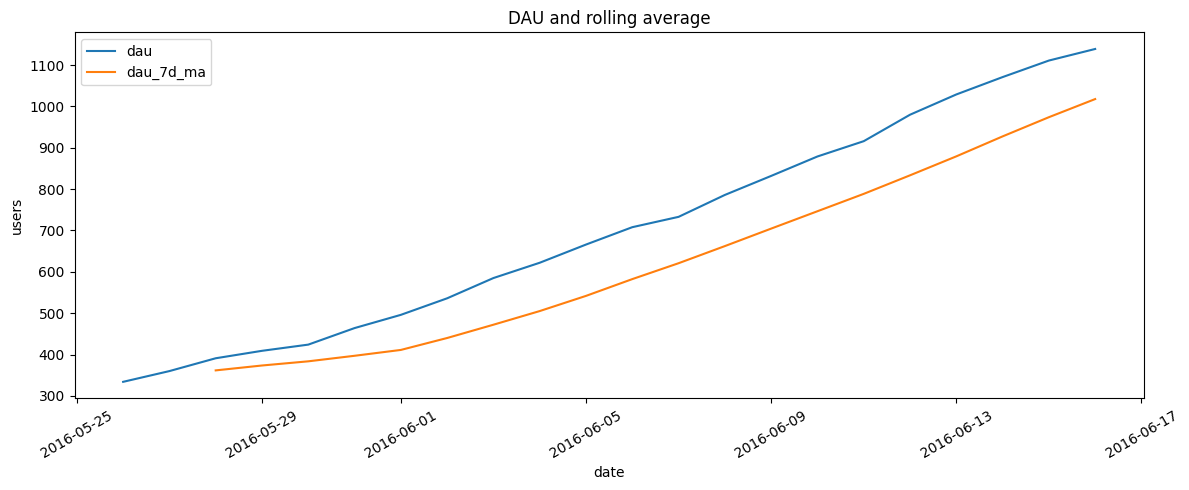

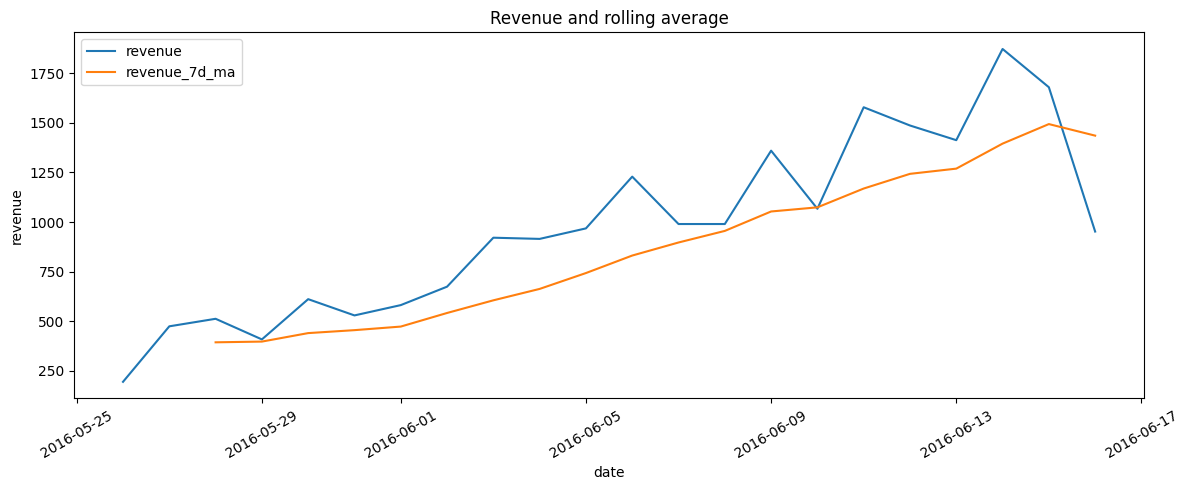

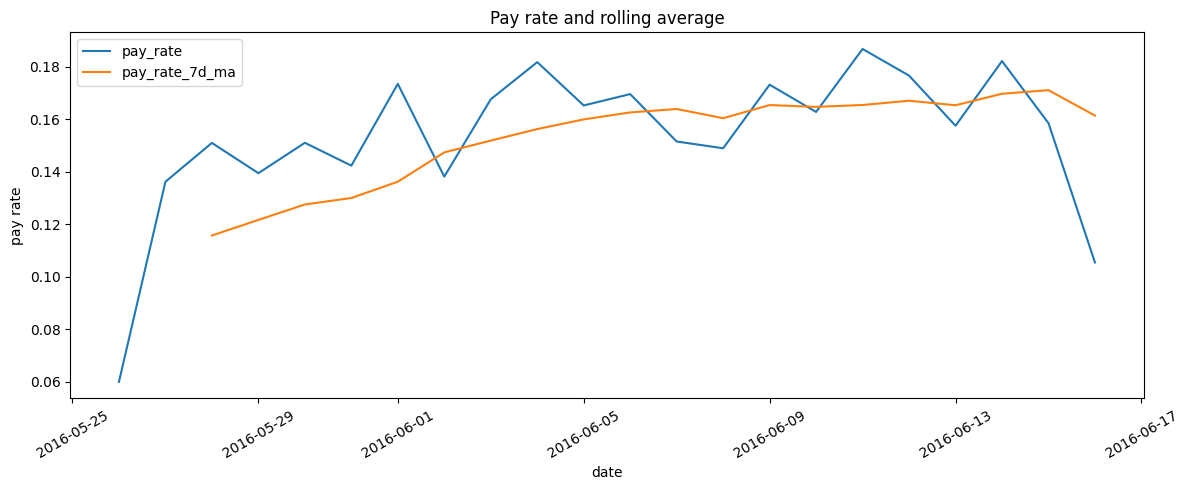

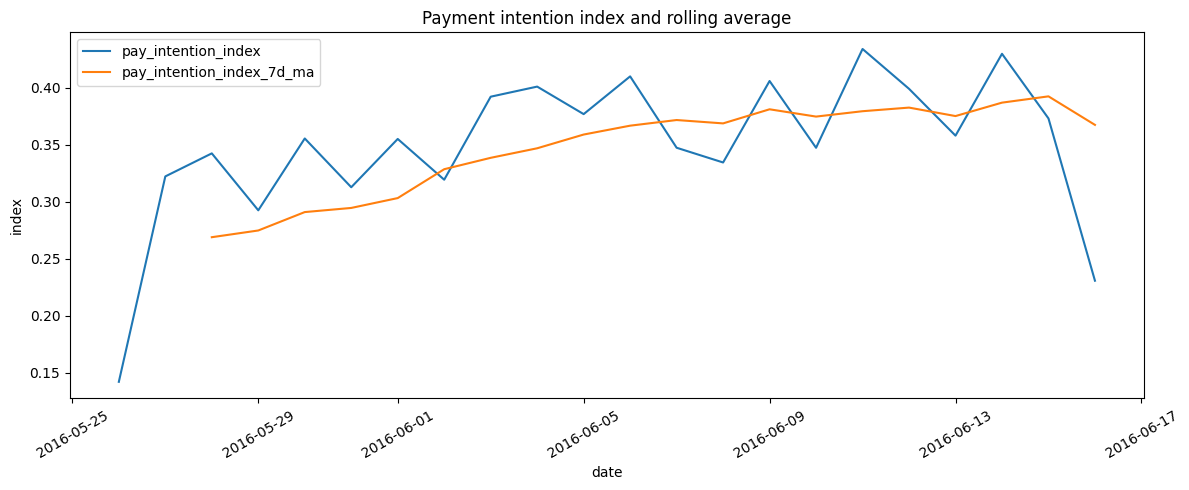

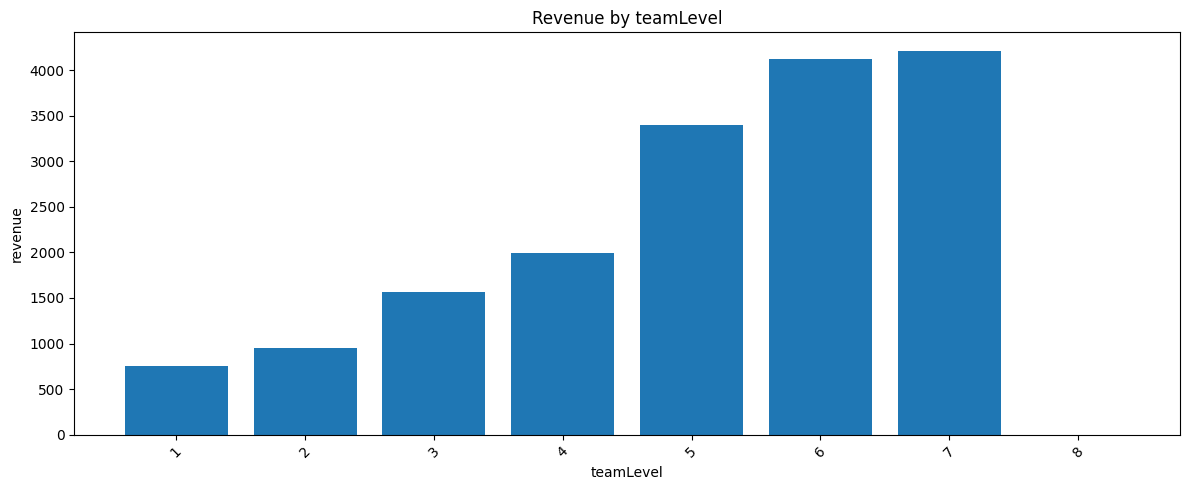

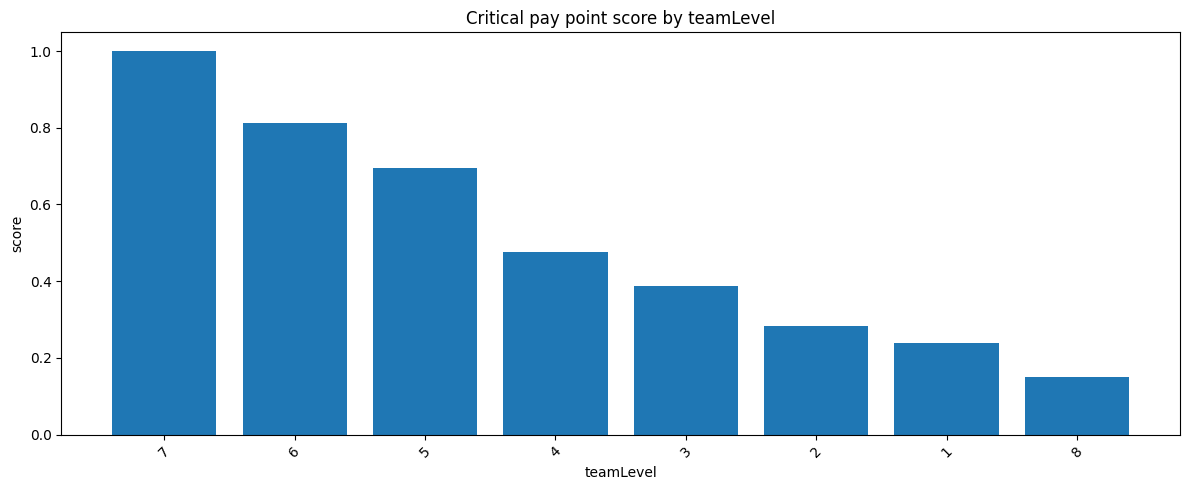

In [12]:
# =============================================================================
# 11. 可视化
# =============================================================================

def save_line_chart(df: pd.DataFrame, x_col: str, y_cols, title: str, ylabel: str, filename: str):
    plt.figure(figsize=(12, 5))
    for y in y_cols:
        if y in df.columns:
            plt.plot(df[x_col], df[y], label=y)
    plt.title(title)
    plt.xlabel("date")
    plt.ylabel(ylabel)
    plt.legend()
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()


save_line_chart(
    ads_daily_metrics,
    "dt",
    ["dau", f"dau_{ROLLING_WINDOW_DAYS}d_ma"],
    "DAU and rolling average",
    "users",
    "01_dau_trend.png",
)

save_line_chart(
    ads_daily_metrics,
    "dt",
    ["revenue", f"revenue_{ROLLING_WINDOW_DAYS}d_ma"],
    "Revenue and rolling average",
    "revenue",
    "02_revenue_trend.png",
)

save_line_chart(
    ads_daily_metrics,
    "dt",
    ["pay_rate", f"pay_rate_{ROLLING_WINDOW_DAYS}d_ma"],
    "Pay rate and rolling average",
    "pay rate",
    "03_pay_rate_trend.png",
)

save_line_chart(
    ads_daily_metrics,
    "dt",
    ["pay_intention_index", f"pay_intention_index_{ROLLING_WINDOW_DAYS}d_ma"],
    "Payment intention index and rolling average",
    "index",
    "04_pay_intention_trend.png",
)

# 关卡收入柱状图
plot_level = level_summary.sort_values("teamLevel").copy()
plt.figure(figsize=(12, 5))
plt.bar(plot_level["teamLevel"].astype(str), plot_level["revenue"])
plt.title("Revenue by teamLevel")
plt.xlabel("teamLevel")
plt.ylabel("revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_level_revenue.png", dpi=150)
plt.show()

# 关键付费点评分
plot_key = ads_key_pay_points.head(15).copy()
plt.figure(figsize=(12, 5))
plt.bar(plot_key["teamLevel"].astype(str), plot_key["critical_pay_point_score"])
plt.title("Critical pay point score by teamLevel")
plt.xlabel("teamLevel")
plt.ylabel("score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_critical_pay_point_score.png", dpi=150)
plt.show()




In [13]:
# =============================================================================
# 12. 导出 CSV + SQLite 数据库，形成可交付的数据中台结果
# =============================================================================

EXPORT_TABLES = {
    # ODS
    "ods_buy_clicks": ods_buy_clicks,
    "ods_user_session": ods_user_session,
    "ods_game_clicks": ods_game_clicks,
    "ods_level_events": ods_level_events,
    "ods_team_assignments": ods_team_assignments,
    "ods_team": ods_team,
    "ods_users": ods_users,

    # DWD
    "dwd_fact_session": dwd_fact_session,
    "dwd_fact_purchase": dwd_fact_purchase,
    "dwd_fact_game_click": dwd_fact_game_click,
    "dwd_fact_level_event": dwd_fact_level_event,
    "dim_user": dim_user,
    "dim_team": dim_team,

    # DWS
    "dws_user_day": dws_user_day,

    # ADS
    "ads_daily_metrics": ads_daily_metrics,
    "ads_dau_decline_runs": ads_dau_decline_runs,
    "ads_pay_intention_decline_runs": ads_pay_intention_decline_runs,
    "ads_pay_rate_decline_runs": ads_pay_rate_decline_runs,
    "ads_revenue_decline_runs": ads_revenue_decline_runs,
    "ads_key_pay_points": ads_key_pay_points,
    "ads_item_summary": ads_item_summary,
    "ads_retention_by_day": ads_retention_by_day,
    "ads_overall_retention": ads_overall_retention,
    "ads_first_pay": ads_first_pay,
    "ads_user_lifecycle": ads_user_lifecycle,
}

# 导出 CSV
for name, df in EXPORT_TABLES.items():
    out_path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(out_path, index=False)

# 导出 SQLite
sqlite_path = OUTPUT_DIR / "pink_flamingo_data_mart.sqlite"
conn = sqlite3.connect(sqlite_path)

for name, df in EXPORT_TABLES.items():
    if df.empty and len(df.columns) == 0:
        print(f"跳过空表: {name}")
        continue

    tmp = df.copy()
    # SQLite 对 datetime 友好度一般，这里转字符串
    for c in tmp.columns:
        if pd.api.types.is_datetime64_any_dtype(tmp[c]):
            tmp[c] = tmp[c].astype(str)
    tmp.to_sql(name, conn, if_exists="replace", index=False)

conn.close()

# 打包输出
zip_base = "/content/pink_flamingo_outputs"
zip_file = shutil.make_archive(zip_base, "zip", OUTPUT_DIR)

print("\n==============================")
print("分析完成")
print("==============================")
print("数据时间范围:", ads_daily_metrics["dt"].min(), "到", ads_daily_metrics["dt"].max())
print("总用户数:", ads_user_lifecycle["userId"].nunique())
print("总收入:", round(dwd_fact_purchase["price"].sum(), 2))
print("总购买次数:", len(dwd_fact_purchase))
print("总会话数:", len(dwd_fact_session))
print("总点击数:", len(dwd_fact_game_click))
print("输出目录:", OUTPUT_DIR)
print("SQLite 数据库:", sqlite_path)
print("打包文件:", zip_file)

display(Markdown("## 最终核心结果索引"))

result_index = pd.DataFrame(
    [
        {"result": "每日指标", "table": "ads_daily_metrics.csv", "description": "DAU、收入、付费率、ARPU、ARPPU、7日均线与下降标记"},
        {"result": "DAU下降周期", "table": "ads_dau_decline_runs.csv", "description": "识别什么时候开始日活明显降低"},
        {"result": "付费意愿下降周期", "table": "ads_pay_intention_decline_runs.csv", "description": "识别什么时候开始付费意愿明显降低"},
        {"result": "付费率下降周期", "table": "ads_pay_rate_decline_runs.csv", "description": "识别付费率下降"},
        {"result": "收入下降周期", "table": "ads_revenue_decline_runs.csv", "description": "识别收入下降"},
        {"result": "关键付费点", "table": "ads_key_pay_points.csv", "description": "按 teamLevel 找关键付费关卡 / 卡点"},
        {"result": "商品付费表现", "table": "ads_item_summary.csv", "description": "按 buyId 看商品收入、购买次数、付费人数"},
        {"result": "留存", "table": "ads_overall_retention.csv / ads_retention_by_day.csv", "description": "整体留存与 cohort 留存"},
        {"result": "首付费", "table": "ads_first_pay.csv", "description": "首付费转化与首付费耗时"},
        {"result": "用户生命周期", "table": "ads_user_lifecycle.csv", "description": "用户级流失、活跃下降、付费下降、LTV"},
        {"result": "SQLite 数据库", "table": "pink_flamingo_data_mart.sqlite", "description": "可直接接 BI / SQL 做二次分析"},
    ]
)
display(result_index)


跳过空表: ads_dau_decline_runs
跳过空表: ads_pay_intention_decline_runs
跳过空表: ads_pay_rate_decline_runs
跳过空表: ads_revenue_decline_runs

分析完成
数据时间范围: 2016-05-26 00:00:00 到 2016-06-16 00:00:00
总用户数: 1193
总收入: 21407.0
总购买次数: 2947
总会话数: 4625
总点击数: 755806
输出目录: /content/pink_flamingo_outputs
SQLite 数据库: /content/pink_flamingo_outputs/pink_flamingo_data_mart.sqlite
打包文件: /content/pink_flamingo_outputs.zip


## 最终核心结果索引

,result,table,description
0,每日指标,ads_daily_metrics.csv,DAU、收入、付费率、ARPU、ARPPU、7日均线与下降标记
1,DAU下降周期,ads_dau_decline_runs.csv,识别什么时候开始日活明显降低
2,付费意愿下降周期,ads_pay_intention_decline_runs.csv,识别什么时候开始付费意愿明显降低
3,付费率下降周期,ads_pay_rate_decline_runs.csv,识别付费率下降
4,收入下降周期,ads_revenue_decline_runs.csv,识别收入下降
5,关键付费点,ads_key_pay_points.csv,按 teamLevel 找关键付费关卡 / 卡点
6,商品付费表现,ads_item_summary.csv,按 buyId 看商品收入、购买次数、付费人数
7,留存,ads_overall_retention.csv / ads_retention_by_d...,整体留存与 cohort 留存
8,首付费,ads_first_pay.csv,首付费转化与首付费耗时
9,用户生命周期,ads_user_lifecycle.csv,用户级流失、活跃下降、付费下降、LTV


# =============================================================================
# 13. 用户付费行为预测模型 (Machine Learning)
# =============================================================================

基于前述整理好的 `ads_user_lifecycle` 数据，构建一个二分类模型来预测用户是否会付费 (`payer_flag`)。
我们将使用用户的活跃度、游戏时长、点击量等行为特征作为输入。

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns

# 1. 选取特征与目标变量
# 为了避免数据穿越（Data Leakage），我们不能使用与收入直接相关的字段（如 total_revenue, pay_days, pay_cnt）
features = [
    'lifetime_days',
    'active_days',
    'total_sessions',
    'total_play_minutes',
    'click_cnt',
    'hit_cnt',
    'hit_rate'
]
target = 'payer_flag'

# 构建建模数据集
df_model = ads_user_lifecycle[features + [target]].copy()

# 填补缺失值
df_model['hit_rate'] = df_model['hit_rate'].fillna(0)
df_model = df_model.fillna(0)

# 2. 划分特征 (X) 和标签 (y)
X = df_model[features]
y = df_model[target]

# 3. 划分训练集和测试集 (80% 训练, 20% 测试)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")
print(f"付费用户占比: {y.mean():.2%}")

训练集大小: (954, 7)
测试集大小: (239, 7)
付费用户占比: 45.77%


=== 分类报告 (Classification Report) ===
              precision    recall  f1-score   support

           0       0.65      0.70      0.68       130
           1       0.61      0.56      0.58       109

    accuracy                           0.64       239
   macro avg       0.63      0.63      0.63       239
weighted avg       0.63      0.64      0.63       239


ROC AUC Score: 0.6656


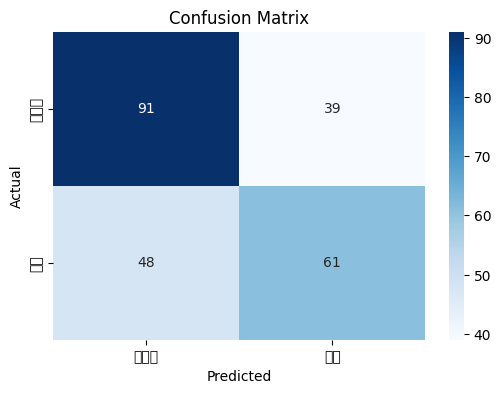

In [15]:
# 4. 训练随机森林分类模型
rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 5. 模型预测与评估
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("=== 分类报告 (Classification Report) ===")
print(classification_report(y_test, y_pred))

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC AUC Score: {auc_score:.4f}")

# 绘制混淆矩阵
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['非付费', '付费'], yticklabels=['非付费', '付费'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

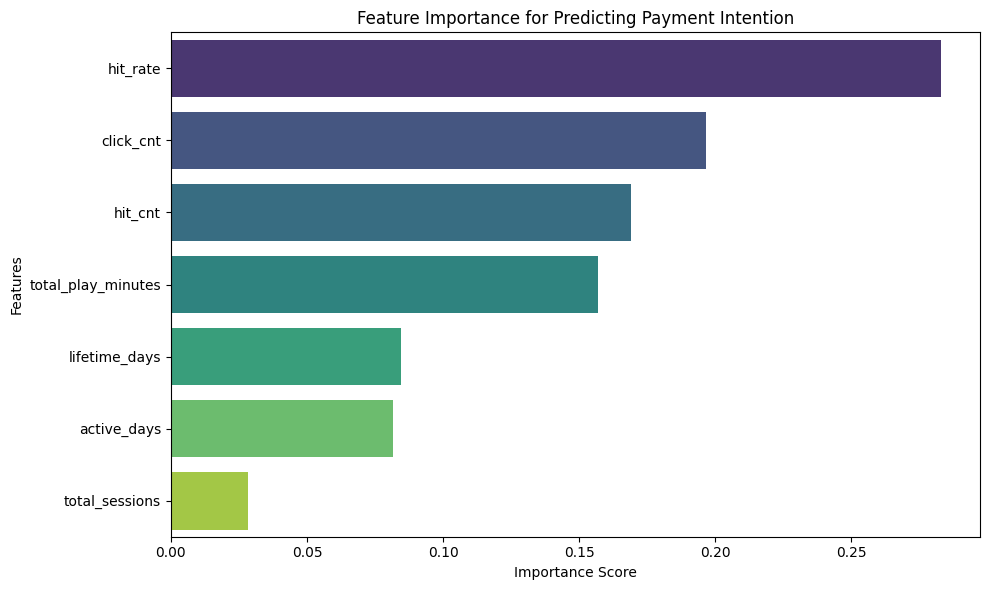

**洞察**: 通过特征重要性，我们可以看出哪些用户行为（比如总游戏时长、总会话数）最能区分出潜在的付费用户。这可以指导运营团队设计针对性的促活或付费引导策略。

In [16]:
# 6. 特征重要性分析 (Feature Importance)
feature_importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title('Feature Importance for Predicting Payment Intention')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

display(Markdown("**洞察**: 通过特征重要性，我们可以看出哪些用户行为（比如总游戏时长、总会话数）最能区分出潜在的付费用户。这可以指导运营团队设计针对性的促活或付费引导策略。"))

# =============================================================================
# 14. 尝试使用 XGBoost 提升预测效果
# =============================================================================

=== XGBoost 分类报告 (Classification Report) ===
              precision    recall  f1-score   support

           0       0.63      0.72      0.67       130
           1       0.60      0.50      0.55       109

    accuracy                           0.62       239
   macro avg       0.62      0.61      0.61       239
weighted avg       0.62      0.62      0.61       239


ROC AUC Score: 0.6420


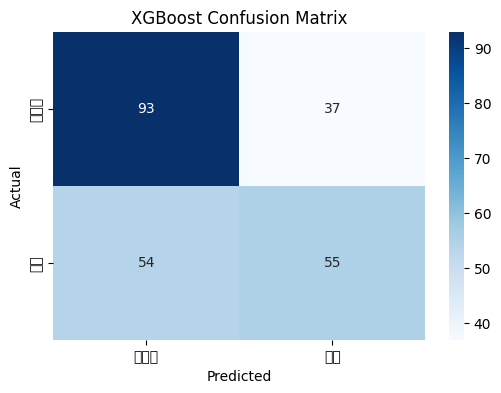

In [17]:
import xgboost as xgb

# 1. 训练 XGBoost 分类模型
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# 2. 模型预测与评估
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost 分类报告 (Classification Report) ===")
print(classification_report(y_test, y_pred_xgb))

auc_score_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"\nROC AUC Score: {auc_score_xgb:.4f}")

# 绘制混淆矩阵
plt.figure(figsize=(6, 4))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['非付费', '付费'], yticklabels=['非付费', '付费'])
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

<Figure size 1000x600 with 0 Axes>

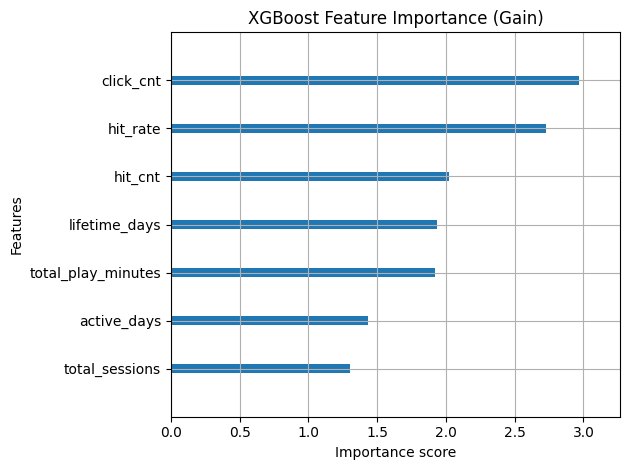

In [18]:
# 3. XGBoost 特征重要性分析 (Feature Importance)
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, importance_type='gain', title='XGBoost Feature Importance (Gain)', show_values=False)
plt.tight_layout()
plt.show()

# =============================================================================
# 15. XGBoost 超参数调优 (Hyperparameter Tuning)
# =============================================================================

In [19]:
from sklearn.model_selection import GridSearchCV

# 1. 定义超参数搜索网格
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6]
}

# 2. 初始化基础 XGBoost 模型
xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# 3. 配置 GridSearchCV (使用 ROC AUC 作为评估指标)
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# 4. 在训练集上执行网格搜索
print("开始超参数调优，请稍候...")
grid_search.fit(X_train, y_train)

print(f"\n最佳参数 (Best Parameters): {grid_search.best_params_}")
print(f"最佳交叉验证 AUC (Best CV AUC): {grid_search.best_score_:.4f}")

# 5. 使用最佳模型进行预测评估
best_xgb_model = grid_search.best_estimator_

y_pred_best = best_xgb_model.predict(X_test)
y_pred_proba_best = best_xgb_model.predict_proba(X_test)[:, 1]

print("\n=== 优化后 XGBoost 分类报告 (Classification Report) ===")
print(classification_report(y_test, y_pred_best))

auc_score_best = roc_auc_score(y_test, y_pred_proba_best)
print(f"\n优化后测试集 ROC AUC Score: {auc_score_best:.4f}")

开始超参数调优，请稍候...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

最佳参数 (Best Parameters): {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
最佳交叉验证 AUC (Best CV AUC): 0.6990

=== 优化后 XGBoost 分类报告 (Classification Report) ===
              precision    recall  f1-score   support

           0       0.62      0.70      0.66       130
           1       0.58      0.50      0.53       109

    accuracy                           0.61       239
   macro avg       0.60      0.60      0.60       239
weighted avg       0.60      0.61      0.60       239


优化后测试集 ROC AUC Score: 0.6452


# =============================================================================
# 16. 重构问题：基于前3天行为预测前7天内是否首购
# =============================================================================

为了业务落地并避免数据穿越，我们将目标重构为 **`paid_within_7d`**（7天内是否首充）。
同时，我们只能使用用户注册后 **前3天 (Day 0, 1, 2)** 的行为数据来作为预测特征。

In [20]:
# 1. 构建新目标变量：注册后7天内是否首充
# 使用 ads_first_pay 表（已包含 first_session_time 和 first_purchase_time）
df_target = ads_first_pay[['userId', 'first_session_time', 'first_purchase_time']].copy()

# 计算首充距离首登的天数
df_target['days_to_first_pay'] = (df_target['first_purchase_time'] - df_target['first_session_time']).dt.total_seconds() / (3600 * 24)

# 定义标签：有购买记录 且 天数 <= 7
df_target['paid_within_7d'] = ((df_target['first_purchase_time'].notna()) & (df_target['days_to_first_pay'] <= 7)).astype(int)

# 2. 提取前3天行为特征 (避免数据穿越)
# dws_user_day 包含了每天的汇总
user_first_dt = dws_user_day.groupby('userId')['dt'].min().reset_index().rename(columns={'dt': 'first_dt'})
dws_with_first = dws_user_day.merge(user_first_dt, on='userId')
dws_with_first['day_from_start'] = (dws_with_first['dt'] - dws_with_first['first_dt']).dt.days

# 仅保留 day_from_start < 3 的记录 (前3天)
early_behavior = dws_with_first[dws_with_first['day_from_start'] < 3]

# 汇总前3天特征
early_features = early_behavior.groupby('userId').agg(
    early_active_days=('active_flag', 'sum'),
    early_sessions=('session_cnt', 'sum'),
    early_play_minutes=('play_minutes', 'sum'),
    early_clicks=('click_cnt', 'sum'),
    early_hits=('hit_cnt', 'sum')
).reset_index()

early_features['early_hit_rate'] = safe_divide(early_features['early_hits'], early_features['early_clicks'])
early_features['early_hit_rate'] = early_features['early_hit_rate'].fillna(0)

# 合并目标与特征
df_early_model = df_target[['userId', 'paid_within_7d']].merge(early_features, on='userId', how='left').fillna(0)

print(f"总样本数: {len(df_early_model)}")
print(f"7天内付费的正样本数: {df_early_model['paid_within_7d'].sum()} (占比: {df_early_model['paid_within_7d'].mean():.2%})")
display(df_early_model.head())

总样本数: 1093
7天内付费的正样本数: 499 (占比: 45.65%)


,userId,paid_within_7d,early_active_days,early_sessions,early_play_minutes,early_clicks,early_hits,early_hit_rate
0,0,0,3,2.0,3900.000000,484.0,47.0,0.097107
1,1,1,3,2.0,4356.916667,133.0,16.0,0.120301
2,2,0,3,2.0,3900.000000,41.0,3.0,0.073171
3,6,0,3,1.0,4470.000000,60.0,4.0,0.066667
4,8,1,3,2.0,4800.000000,115.0,11.0,0.095652


=== 预测前7天内是否首购 (基于前3天特征) ===
              precision    recall  f1-score   support

           0       0.56      0.51      0.54       119
           1       0.47      0.52      0.50       100

    accuracy                           0.52       219
   macro avg       0.52      0.52      0.52       219
weighted avg       0.52      0.52      0.52       219


ROC AUC Score: 0.5217


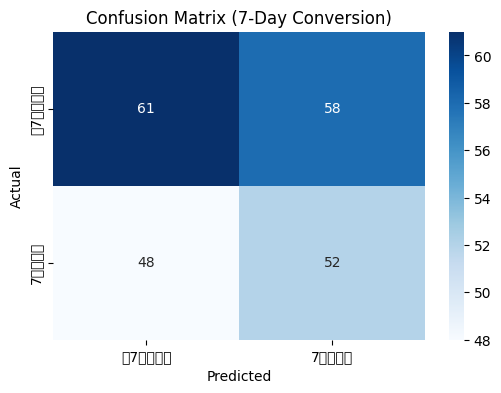

In [21]:
from sklearn.ensemble import RandomForestClassifier

# 3. 划分训练集和测试集
features_early = [
    'early_active_days',
    'early_sessions',
    'early_play_minutes',
    'early_clicks',
    'early_hits',
    'early_hit_rate'
]

X_early = df_early_model[features_early]
y_early = df_early_model['paid_within_7d']

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_early, y_early, test_size=0.2, random_state=42, stratify=y_early
)

# 4. 训练模型
rf_early = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')
rf_early.fit(X_train_e, y_train_e)

# 5. 模型预测与评估
y_pred_e = rf_early.predict(X_test_e)
y_prob_e = rf_early.predict_proba(X_test_e)[:, 1]

print("=== 预测前7天内是否首购 (基于前3天特征) ===")
print(classification_report(y_test_e, y_pred_e))

auc_e = roc_auc_score(y_test_e, y_prob_e)
print(f"\nROC AUC Score: {auc_e:.4f}")

# 绘制混淆矩阵
plt.figure(figsize=(6, 4))
cm_e = confusion_matrix(y_test_e, y_pred_e)
sns.heatmap(cm_e, annot=True, fmt='d', cmap='Blues', xticklabels=['非7天内付费', '7天内付费'], yticklabels=['非7天内付费', '7天内付费'])
plt.title('Confusion Matrix (7-Day Conversion)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# =============================================================================
# 17. 特征工程升级 (Advanced Feature Engineering)
# =============================================================================

引入静态特征 (国家)、设备特征 (平台) 以及时间上下文 (首登小时、星期)，并加上前3天的最高关卡数，以丰富模型的输入信息。

In [22]:
# 1. 提取用户静态特征: 国家 (country)
user_static = ods_users[['userId', 'country']].copy()

# 2. 提取用户首次 Session 的上下文信息: 平台 (platformType) 和 首次登录时间特征
first_sessions = dwd_fact_session.sort_values(['userId', 'sessionStartTime']).groupby('userId').first().reset_index()
first_sessions['first_platform'] = first_sessions['platformType'].fillna('unknown')
first_sessions['first_session_hour'] = first_sessions['sessionStartTime'].dt.hour
first_sessions['first_session_dow'] = first_sessions['sessionStartTime'].dt.dayofweek

user_context = user_static.merge(
    first_sessions[['userId', 'first_platform', 'first_session_hour', 'first_session_dow']],
    on='userId', how='left'
)

# 3. 提取前3天达到的最高关卡 (early_max_level)
early_max_level = early_behavior.groupby('userId')['max_team_level'].max().reset_index().rename(columns={'max_team_level': 'early_max_level'})

# 4. 合并所有特征
df_advanced = df_early_model.merge(user_context, on='userId', how='left').merge(early_max_level, on='userId', how='left')

# 5. 类别特征独热编码 (One-Hot Encoding)
categorical_cols = ['country', 'first_platform']
df_advanced = pd.get_dummies(df_advanced, columns=categorical_cols, dummy_na=True)

# 填充缺失值
df_advanced = df_advanced.fillna(0)

print(f"升级后特征维度: {df_advanced.shape[1] - 2} 个特征")
display(df_advanced.head())

升级后特征维度: 256 个特征


,userId,paid_within_7d,early_active_days,early_sessions,early_play_minutes,early_clicks,early_hits,early_hit_rate,first_session_hour,first_session_dow,early_max_level,country_AD,country_AE,country_AF,country_AG,country_AI,country_AL,country_AM,country_AN,country_AO,country_AQ,country_AR,country_AS,country_AT,country_AU,country_AW,country_AZ,country_BA,country_BB,country_BD,country_BE,country_BF,country_BG,country_BH,country_BI,country_BJ,country_BM,country_BN,country_BO,country_BR,country_BS,country_BT,country_BV,country_BW,country_BY,country_BZ,country_CA,country_CC,country_CD,country_CF,country_CG,country_CH,country_CI,country_CK,country_CL,country_CM,country_CN,country_CO,country_CR,country_CU,country_CV,country_CX,country_CY,country_CZ,country_DE,country_DJ,country_DK,country_DM,country_DO,country_DZ,country_EC,country_EE,country_EG,country_EH,country_ER,country_ES,country_ET,country_FI,country_FJ,country_FK,country_FM,country_FO,country_FR,country_GA,country_GB,country_GD,country_GE,country_GF,country_GH,country_GI,country_GL,country_GM,country_GN,country_GP,country_GQ,country_GR,country_GS,country_GT,country_GU,country_GW,...,country_MU,country_MV,country_MW,country_MX,country_MY,country_MZ,country_NC,country_NE,country_NF,country_NG,country_NI,country_NL,country_NO,country_NP,country_NR,country_NU,country_NZ,country_OM,country_PA,country_PE,country_PF,country_PG,country_PH,country_PK,country_PL,country_PM,country_PN,country_PR,country_PS,country_PT,country_PW,country_PY,country_QA,country_RE,country_RO,country_RS,country_RU,country_RW,country_SA,country_SB,country_SC,country_SD,country_SE,country_SG,country_SH,country_SI,country_SJ,country_SK,country_SL,country_SM,country_SN,country_SO,country_SR,country_ST,country_SV,country_SY,country_SZ,country_TC,country_TD,country_TF,country_TG,country_TH,country_TJ,country_TK,country_TM,country_TN,country_TO,country_TP,country_TR,country_TT,country_TV,country_TW,country_TZ,country_UA,country_UG,country_UM,country_US,country_UY,country_UZ,country_VA,country_VC,country_VE,country_VG,country_VI,country_VN,country_VU,country_WF,country_WS,country_YE,country_YT,country_ZA,country_ZM,country_ZW,country_nan,first_platform_android,first_platform_iphone,first_platform_linux,first_platform_mac,first_platform_windows,first_platform_nan
0,0,0,3,2.0,3900.000000,484.0,47.0,0.097107,21.0,1.0,2.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
1,1,1,3,2.0,4356.916667,133.0,16.0,0.120301,14.0,3.0,2.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,

=== 升级特征后：预测前7天内是否首购 ===
              precision    recall  f1-score   support

           0       0.62      0.60      0.61       119
           1       0.54      0.56      0.55       100

    accuracy                           0.58       219
   macro avg       0.58      0.58      0.58       219
weighted avg       0.58      0.58      0.58       219


优化特征后的 ROC AUC Score: 0.5446


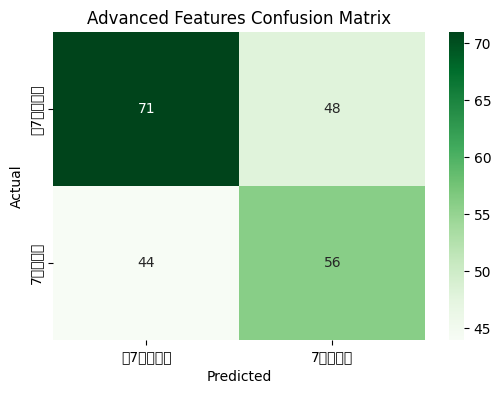

<Figure size 1000x600 with 0 Axes>

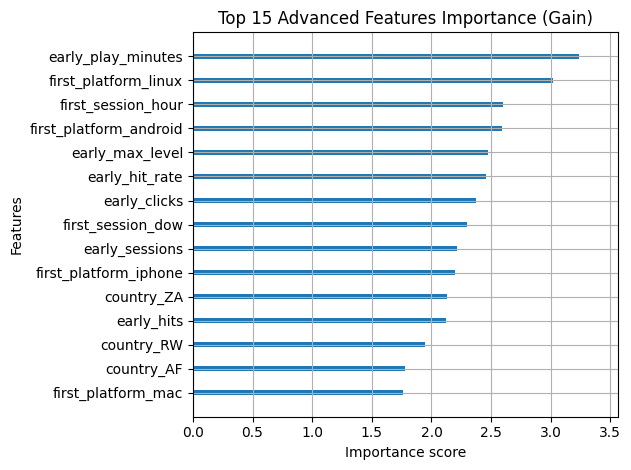

In [23]:
import xgboost as xgb

# 6. 准备训练数据
drop_cols = ['userId', 'paid_within_7d']
features_adv = [c for c in df_advanced.columns if c not in drop_cols]

X_adv = df_advanced[features_adv]
y_adv = df_advanced['paid_within_7d']

# 划分数据集
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_adv, y_adv, test_size=0.2, random_state=42, stratify=y_adv
)

# 7. 训练 XGBoost 模型
xgb_adv = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=(len(y_train_a) - sum(y_train_a)) / sum(y_train_a) # 处理样本轻微不平衡
)
xgb_adv.fit(X_train_a, y_train_a)

# 8. 预测与评估
y_pred_a = xgb_adv.predict(X_test_a)
y_prob_a = xgb_adv.predict_proba(X_test_a)[:, 1]

print("=== 升级特征后：预测前7天内是否首购 ===")
print(classification_report(y_test_a, y_pred_a))

auc_a = roc_auc_score(y_test_a, y_prob_a)
print(f"\n优化特征后的 ROC AUC Score: {auc_a:.4f}")

# 混淆矩阵
plt.figure(figsize=(6, 4))
cm_a = confusion_matrix(y_test_a, y_pred_a)
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Greens', xticklabels=['非7天内付费', '7天内付费'], yticklabels=['非7天内付费', '7天内付费'])
plt.title('Advanced Features Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 9. 可视化新特征的重要性 (Top 15)
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_adv, importance_type='gain', max_num_features=15, title='Top 15 Advanced Features Importance (Gain)', show_values=False)
plt.tight_layout()
plt.show()

# =============================================================================
# 18. 使用深度学习：Tabular Transformer 尝试提升预测上限
# =============================================================================

Transformer 模型在表格数据（Tabular Data）上也有一些应用。在这里，我们构建一个简单的架构：将数值和独热编码的类别特征统一映射为高维 Embedding（嵌入向量），并通过自注意力机制（Self-Attention）捕捉特征之间的非线性交叉关系。

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

# 1. 数据标准化 (StandardScaler)
# 神经网络对输入特征的尺度非常敏感，因此必须先将特征缩放到均值为0，方差为1的分布
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_a)
X_test_scaled = scaler.transform(X_test_a)

# 2. 转换为 PyTorch Tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_a.values, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_a.values, dtype=torch.float32).unsqueeze(1)

# 3. 创建 DataLoader 批量加载数据
batch_size = 64
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"训练集 Tensor 形状: {X_train_t.shape}")
print(f"测试集 Tensor 形状: {X_test_t.shape}")

训练集 Tensor 形状: torch.Size([874, 256])
测试集 Tensor 形状: torch.Size([219, 256])


In [29]:
# 4. 定义 Tabular Transformer 模型
class SimpleTabularTransformer(nn.Module):
    def __init__(self, num_features, d_model=16, nhead=4, num_layers=2, dropout=0.2):
        super(SimpleTabularTransformer, self).__init__()

        # 将每个标量特征映射为 d_model 维度的向量 (Token Embedding)
        self.feature_embedding = nn.Linear(1, d_model)

        # Transformer 编码器层
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            batch_first=True # 输入格式为 (batch, seq_len, feature_dim)
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 分类头 (Classifier Head)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1) # 输出 logits (不加 Sigmoid，因为损失函数包含)
        )

    def forward(self, x):
        # x 原始形状: (batch_size, num_features)
        x = x.unsqueeze(-1) # 变为 (batch_size, num_features, 1) 相当于 seq_len = num_features

        # 映射特征
        x = self.feature_embedding(x) # 变为 (batch_size, num_features, d_model)

        # 通过 Transformer 编码器捕捉特征间关系
        x = self.transformer_encoder(x)

        # 全局平均池化 (Global Average Pooling)，综合所有特征的信息
        x = x.mean(dim=1) # 变为 (batch_size, d_model)

        # 线性分类
        out = self.classifier(x)
        return out

# 实例化模型
num_features = X_train_t.shape[1]
transformer_model = SimpleTabularTransformer(num_features=num_features, d_model=16, nhead=4, num_layers=2)
print(transformer_model)

SimpleTabularTransformer(
  (feature_embedding): Linear(in_features=1, out_features=16, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
        )
        (linear1): Linear(in_features=16, out_features=32, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=32, out_features=16, bias=True)
        (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=16, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=1, b

In [30]:
# 5. 训练 Transformer 模型 (加入正则化、调度器与早停)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transformer_model.to(device)

# 计算正负样本权重处理类别不平衡
pos_weight = (len(y_train_a) - sum(y_train_a)) / sum(y_train_a)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))

# AdamW 优化器 (增加 weight_decay 增强正则化，防止小数据集过拟合)
optimizer = optim.AdamW(transformer_model.parameters(), lr=1e-3, weight_decay=1e-2)

# 学习率调度器
epochs = 50
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

print("开始训练 Tabular Transformer (启用早停与学习率调度)...")
best_val_loss = float('inf')
patience = 10
patience_counter = 0
best_model_state = None

for epoch in range(epochs):
    transformer_model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = transformer_model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()

        # 梯度裁剪，防止梯度爆炸
        torch.nn.utils.clip_grad_norm_(transformer_model.parameters(), max_norm=1.0)

        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()

    # 验证集评估
    transformer_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = transformer_model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()

    val_loss /= len(test_loader)
    train_loss = epoch_loss / len(train_loader)

    # 早停逻辑
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = transformer_model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if patience_counter >= patience:
        print(f"\n在 Epoch {epoch+1} 触发早停，最佳 Val Loss: {best_val_loss:.4f}")
        break

print("训练完成！")
# 恢复到验证集上表现最好的模型参数
if best_model_state is not None:
    transformer_model.load_state_dict(best_model_state)
    print("已恢复最佳模型权重。")


开始训练 Tabular Transformer (启用早停与学习率调度)...
Epoch 01/50, Train Loss: 0.7594, Val Loss: 0.7528
Epoch 05/50, Train Loss: 0.7531, Val Loss: 0.7518
Epoch 10/50, Train Loss: 0.7526, Val Loss: 0.7522
Epoch 15/50, Train Loss: 0.7544, Val Loss: 0.7521

在 Epoch 15 触发早停，最佳 Val Loss: 0.7518
训练完成！
已恢复最佳模型权重。


=== Tabular Transformer 分类报告 ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       119
           1       0.46      1.00      0.63       100

    accuracy                           0.46       219
   macro avg       0.23      0.50      0.31       219
weighted avg       0.21      0.46      0.29       219


优化特征后 Transformer 的 ROC AUC Score: 0.4940


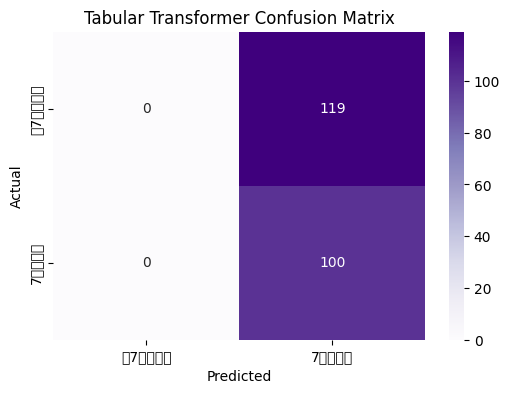

In [31]:
# 6. 模型预测与效果评估
transformer_model.eval()
with torch.no_grad():
    X_test_device = X_test_t.to(device)
    test_outputs = transformer_model(X_test_device)
    # 使用 Sigmoid 将 logits 转换为概率
    y_pred_prob_nn = torch.sigmoid(test_outputs).cpu().numpy().flatten()
    # 阈值 0.5 划分类别
    y_pred_nn = (y_pred_prob_nn > 0.5).astype(int)

print("=== Tabular Transformer 分类报告 ===")
print(classification_report(y_test_a, y_pred_nn))

auc_nn = roc_auc_score(y_test_a, y_pred_prob_nn)
print(f"\n优化特征后 Transformer 的 ROC AUC Score: {auc_nn:.4f}")

# 绘制混淆矩阵
plt.figure(figsize=(6, 4))
cm_nn = confusion_matrix(y_test_a, y_pred_nn)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples', xticklabels=['非7天内付费', '7天内付费'], yticklabels=['非7天内付费', '7天内付费'])
plt.title('Tabular Transformer Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# =============================================================================
# 19. 特征选择与重训练 (Feature Selection & Retraining)
# =============================================================================

我们利用前面表现较好的 XGBoost 模型的特征重要性（Gain）来筛选出 Top 30 的关键特征，去除噪声特征，从而简化模型并可能提升泛化能力。

In [32]:
import numpy as np

# 1. 获取 XGBoost 特征重要性
importance_dict = xgb_adv.get_booster().get_score(importance_type='gain')

# 将特征重要性转为 DataFrame 并排序
feat_imp_df = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Gain': list(importance_dict.values())
}).sort_values(by='Gain', ascending=False)

# 2. 选取 Top 30 特征
top_30_features = feat_imp_df['Feature'].head(30).tolist()
print("Top 30 特征:")
print(top_30_features)

# 3. 使用选定的特征重新划分数据集
X_train_sel = X_train_a[top_30_features]
X_test_sel = X_test_a[top_30_features]

print(f"\n特征筛选后训练集大小: {X_train_sel.shape}")

Top 30 特征:
['early_play_minutes', 'first_platform_linux', 'first_session_hour', 'first_platform_android', 'early_max_level', 'early_hit_rate', 'early_clicks', 'first_session_dow', 'early_sessions', 'first_platform_iphone', 'country_ZA', 'early_hits', 'country_RW', 'country_AF', 'first_platform_mac', 'country_TK', 'country_VC', 'country_CA', 'country_GU', 'country_FJ', 'country_LK', 'first_platform_windows', 'country_PL', 'country_WS', 'country_BB', 'country_UG', 'country_VE', 'country_GE', 'country_GP', 'country_KR']

特征筛选后训练集大小: (874, 30)


=== 筛选 Top 30 特征后 XGBoost 分类报告 ===
              precision    recall  f1-score   support

           0       0.59      0.55      0.57       119
           1       0.50      0.54      0.52       100

    accuracy                           0.54       219
   macro avg       0.54      0.54      0.54       219
weighted avg       0.55      0.54      0.54       219


筛选特征后的 ROC AUC Score: 0.5446


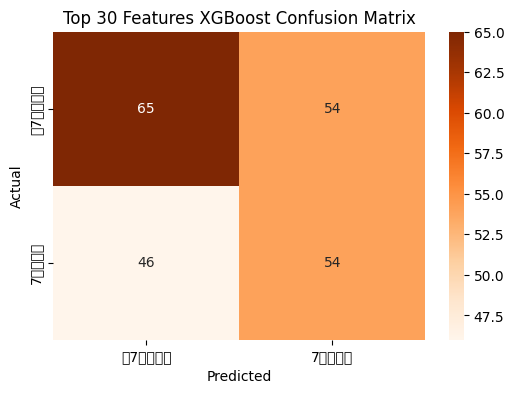

In [33]:
# 4. 重新训练 XGBoost 模型
xgb_sel = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=(len(y_train_a) - sum(y_train_a)) / sum(y_train_a)
)
xgb_sel.fit(X_train_sel, y_train_a)

# 5. 预测与评估
y_pred_sel = xgb_sel.predict(X_test_sel)
y_prob_sel = xgb_sel.predict_proba(X_test_sel)[:, 1]

print("=== 筛选 Top 30 特征后 XGBoost 分类报告 ===")
print(classification_report(y_test_a, y_pred_sel))

auc_sel = roc_auc_score(y_test_a, y_prob_sel)
print(f"\n筛选特征后的 ROC AUC Score: {auc_sel:.4f}")

# 混淆矩阵
plt.figure(figsize=(6, 4))
cm_sel = confusion_matrix(y_test_a, y_pred_sel)
sns.heatmap(cm_sel, annot=True, fmt='d', cmap='Oranges', xticklabels=['非7天内付费', '7天内付费'], yticklabels=['非7天内付费', '7天内付费'])
plt.title('Top 30 Features XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()